Data
├ Water Data
│ ├ data_2012.csv
│   ├ ymdhm : 년월일시분
│   ├ swl : 팔당댐 현재수위 (단위: El.m)
│   ├ inf : 팔당댐 유입량 (단위: m^3/s)
│   ├ sfw : 팔당댐 저수량 (단위: 만m^3)
│   ├ ecpc : 팔당댐 공용량 (단위: 백만m^3)
│   ├ tototf : 총 방류량 (단위: m^3/s)
│   ├ tide_level : 강화대교 조위 (단위: cm)
│   ├ wl_1018662 : 청담대교 수위 (단위: cm)
│   ├ fw_1018662 : 청담대교 유량 (단위: m^3/s)
│   ├ wl_1018680 : 잠수교 수위 (단위: cm)
│   ├ fw_1018680 : 잠수교 유량 (단위: m^3/s)
│   ├ wl_1018683 : 한강대교 수위 (단위: cm)
│   ├ fw_1018683 : 한강대교 유량 (단위: m^3/s)
│   ├ wl_1019630 : 행주대교 수위 (단위: cm)
│   └ fw_1019630 : 행주대교 유량 (단위: m^3/s)
│ ├ data_2013.csv
…
└ └ data_2022.csv
└ RainFall Data
│ ├ rf_2012.csv
│   ├ YMDHM : 년월일시분
│   ├ rf_10184100 : 대곡교 강수량
│   ├ rf_10184110 : 진관교 강수량
│   └ rf_10184140 : 송정동 강수량
│ ├ rf_2013.csv
…
└ └ rf_2022.csv

In [1]:
_useless_feature_names = [
    'fw_1018680', 'wl_1018645', 'fw_1018645', 'wl_1018655', 'fw_1018655', 
    'wl_1018660', 'fw_1018660', 'wl_1018664', 'fw_1018664', 'fw_1018669', 
    'wl_1018685', 'fw_1018685', 'fw_1007604', 'fw_1007642', 'fw_1007653', 
    'fw_1007656', 'fw_1007672', 'fw_1007697', 'wl_1018605', 'fw_1018605', 
    'wl_1018611', 'fw_1018611', 'wl_1018628', 'fw_1018628', 'fw_1018638', 
    'fw_1019667', 'fw_1022644', 'wl_1022659', 'fw_1022659', 'fw_1101609', 
    'wl_1022665', 'fw_1022665', 'fw_1101615', 'fw_1101625', 
    'wl_1101675', 'fw_1101675', 'wl_1101685', 'fw_1101685', 
    'wl_1101690', 'fw_1101690', 'wl_1202630', 'fw_1202630', 
    'wl_1202660', 'fw_1202660', 'wl_1202670', 'fw_1202670', 
    
    'fw_1007630', 'fw_1007634', 'fw_1007639', 'fw_1007649', 'fw_1007664',
    'wl_1015639', 'fw_1015680', 'fw_1019637', 'fw_1019675', 'wl_1021660',
    'fw_1021660', 'fw_1023640', 'fw_1023662', 'fw_1101696'
]
_unimportant_feature_names = [
    'fw_1007620', 'fw_1007633', 'fw_1007641', 'fw_1007662', 'fw_1013620',
    'fw_1013652', 'fw_1015630', 'fw_1015639', 'fw_1015640', 'fw_1016655', 
    'fw_1016670', 'fw_1016695', 'fw_1017678', 'fw_1017690', 'fw_1018658', 
    'fw_1019620', 'fw_1019635', 'fw_1019636', 'fw_1019680', 'fw_1021670', 
    'fw_1022642', 'fw_1022643', 'fw_1022645', 'fw_1022662', 'fw_1022664', 
    'fw_1022666', 'fw_1022668', 'fw_1023680', 'fw_1101695', 'rf_10074020', 
    'rf_10154032', 'rf_10184030', 'rf_10184050', 'rf_10184070', 'rf_10184232', 
    'rf_10214020', 'rf_11014130', 'rf_11014140', 'rf_12024010', 'rf_12024020', 
    'wl_1007604', 'wl_1007642', 'wl_1007653', 'wl_1007656', 'wl_1007672', 
    'wl_1007697', 'wl_1017678', 'wl_1018638', 'wl_1018658', 'wl_1018669',
    'wl_1019636', 'wl_1019637', 'wl_1019667', 'wl_1019680', 'wl_1022642',
    'wl_1022643', 'wl_1022644', 'wl_1022645', 'wl_1022662', 'wl_1022664', 
    'wl_1022666', 'wl_1022668', 'wl_1101609', 'wl_1101615', 'wl_1101625'
]

In [2]:
_input_path = '../data'
# _input_path = '/data'

import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

def load_data(data_type):
    dataset_path = f'{_input_path}/{data_type}_data'
    dfs = []
    for file_name in sorted(os.listdir(f'{dataset_path}/')):
        if not file_name.endswith('.csv'):
            continue
        df = pd.read_csv(f'{dataset_path}/{file_name}', parse_dates=['ymdhm'])
        dfs.append( df )
    return pd.concat(dfs, axis=0, ignore_index=True)


def submit(Y_pred):
    '''
    Renders .csv file for submission.
    '''
    df = pd.read_csv(f'{_input_path}/sample_submission.csv')
    df['wl_1018662'] = Y_pred[:, 0]
    df['wl_1018680'] = Y_pred[:, 1]
    df['wl_1018683'] = Y_pred[:, 2]
    df['wl_1019630'] = Y_pred[:, 3]
    df.to_csv(f'../output/submission.csv', index=False)
    
def competition_metric(Y_true, Y_pred):
    '''
    Returns score for the current competition.
    '''
    l2_mean = np.mean(np.square(Y_true - Y_pred), axis=0)
    r_sq = 1 - (l2_mean / np.var(Y_true, axis=0))
    if np.isnan(r_sq).any() or (r_sq <= 0).any():
        return 999.
    return np.mean(np.sqrt(l2_mean) / r_sq)

In [3]:
def load_extended_data():
    wlobscds = ['1018662', '1018680', '1018683', '1019630']
    rfobscds = ['10184100', '10184110', '10184140']
    
    wlobscds += ['1018640', '1018645', '1018655', '1018658', '1018660', 
                '1018664', '1018669', '1018670', '1018675', '1018685',
                '1018695', '1018697']
    rfobscds += ['10184070', '10184080', '10184190', '10184200', '10194030']
    
    wlobscds += ['1007604', '1007605', '1007615', '1007617', '1007620', 
                 '1007625', '1007630', '1007633', '1007634', '1007635', 
                 '1007639', '1007640', '1007641', '1007642', '1007645', 
                 '1007649', '1007650', '1007653', '1007655', '1007656', 
                 '1007660', '1007662', '1007664', '1007672', '1007680', 
                 '1007685', '1007690', '1007697', '1013620', '1013652', 
                 '1013655', '1015630', '1015639', '1015640', '1015644', 
                 '1015645', '1015680', '1016607', '1016650', '1016655', 
                 '1016660', '1016670', '1016695', '1017678', '1017690', 
                 '1018605', '1018610', '1018611', '1018620', '1018623', 
                 '1018625', '1018628', '1018630', '1018635', '1018638', 
                 '1018650', '1018665', '1018690', '1018693', '1019620',
                 '1019635', '1019636', '1019637', '1019667', 
                 '1019675', '1019680', '1021650', '1021660', '1021670', 
                 '1021680', '1022640', '1022642', '1022643', '1022644', 
                 '1022645', '1022648', '1022650', '1022655', '1022659', 
                 '1022662', '1022664', '1022665', '1022666', '1022668', 
                 '1022670', '1022680', '1023640', '1023660', '1023662', 
                 '1023670', '1023680', '1101605', '1101609', '1101610', 
                 '1101615', '1101620', '1101625', '1101635', '1101645', 
                 '1101650', '1101663', '1101665', '1101670', '1101675', 
                 '1101680', '1101685', '1101690', '1101695', '1101696', 
                 '1202630', '1202660', '1202670']
    rfobscds += ['10064030', '10074010', '10074020', '10074030', '10074040', 
                 '10074060', '10074070', '10074080', '10074090', '10074100', 
                 '10074110', '10074120', '10074170', '10074175', '10134020', 
                 '10134030', '10134045', '10134140', '10154010', '10154020', 
                 '10154030', '10154032', '10154035', '10164010', '10164020', 
                 '10164030', '10164040', '10164050', '10164060', '10164070', 
                 '10164075', '10164080', '10174020', '10184010', '10184020', 
                 '10184030', '10184040', '10184050', '10184060', '10184090', 
                 '10184120', '10184125', '10184130', '10184150', 
                 '10184160', '10184170', '10184180', '10184210', '10184220', 
                 '10184230', '10184232', '10194010', '10204010', '10204020', 
                 '10214010', '10214020', '10214030', '10224010', '10224020', 
                 '10224040', '10224050', '10224060', '10224070', '10224090', 
                 '10234010', '10234020', '10234030', '10234040', '11014010', 
                 '11014020', '11014030', '11014040', '11014060', '11014070', 
                 '11014080', '11014090', '11014100', '11014120', '11014130', 
                 '11014140', '12024010', '12024020', ]
    
    obs_post_ids = ['DT_0032']
    obs_post_ids += ['DT_0044', 'DT_0058']

    date = 20220822
    df_dm = pd.read_csv(
        f'{_input_path}/OpenAPI_merged/dm_{date}.csv', 
        parse_dates=['ymdhm'], 
        na_values=[' ', '##########'])
    
    df_wl = []
    for wlobscd in wlobscds:
        df_wl.append( pd.read_csv(
            f'{_input_path}/OpenAPI_merged/wl_{wlobscd}_{date}.csv', 
            na_values=[' ', '##########'])
        )
    df_wl = pd.concat(df_wl, axis=1).drop(columns=['ymdhm'])

    df_rf = []
    for rfobscd in rfobscds:
        df_rf.append( pd.read_csv(
            f'{_input_path}/OpenAPI_merged/rf_{rfobscd}_{date}.csv', 
            na_values=[' ', '##########']) 
                    )
    df_rf = pd.concat(df_rf, axis=1).drop(columns=['ymdhm'])

    df_tide = []
    for obs_post_id in obs_post_ids:
        df = pd.read_csv(f'{_input_path}/OpenAPI_merged/tide_level_{obs_post_id}_{date}.csv', parse_dates=['ymdhm'])
        df = df.drop_duplicates()
        df = df.set_index('ymdhm', drop=True)
        df = df.reindex(df.index.ceil('10min').drop_duplicates(), method='ffill')
        df = df.reindex(pd.date_range(pd.Timestamp(2012, 1, 1), pd.Timestamp(2022, 7, 31, 23, 50), freq='10min'))
        df = df.reset_index(drop=True)
        df_tide.append(df)
    df_tide = pd.concat(df_tide, axis=1)
    
    df = pd.concat([df_dm, df_wl, df_tide, df_rf], axis=1)
    df = df.drop(columns=_useless_feature_names + _unimportant_feature_names)
    for name in df.columns:
        if name == 'ymdhm':
            continue
        df[name] = df[name].astype(np.float32)
    return df

In [4]:
df = load_extended_data()
df_old = pd.merge(load_data('water'), load_data('rf'), on='ymdhm')
df_old = df_old.set_index('ymdhm', drop=True)
df_old = df_old.reindex(pd.date_range(pd.Timestamp(2012, 1, 1), pd.Timestamp(2022, 7, 31, 23, 50), freq='10min'))
df_old = df_old.reset_index().rename(columns={'index': 'ymdhm'})
# df = cleanup(df)

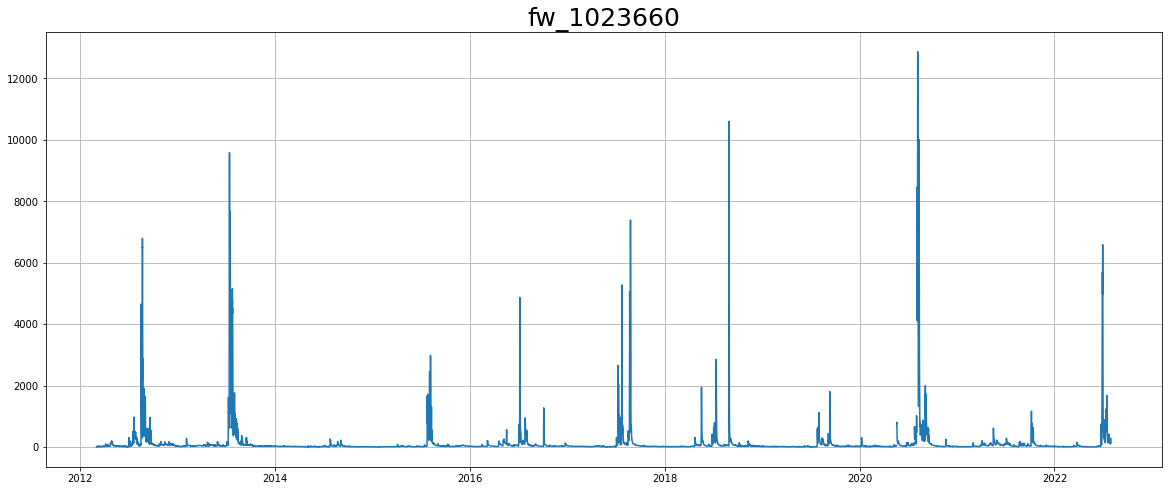

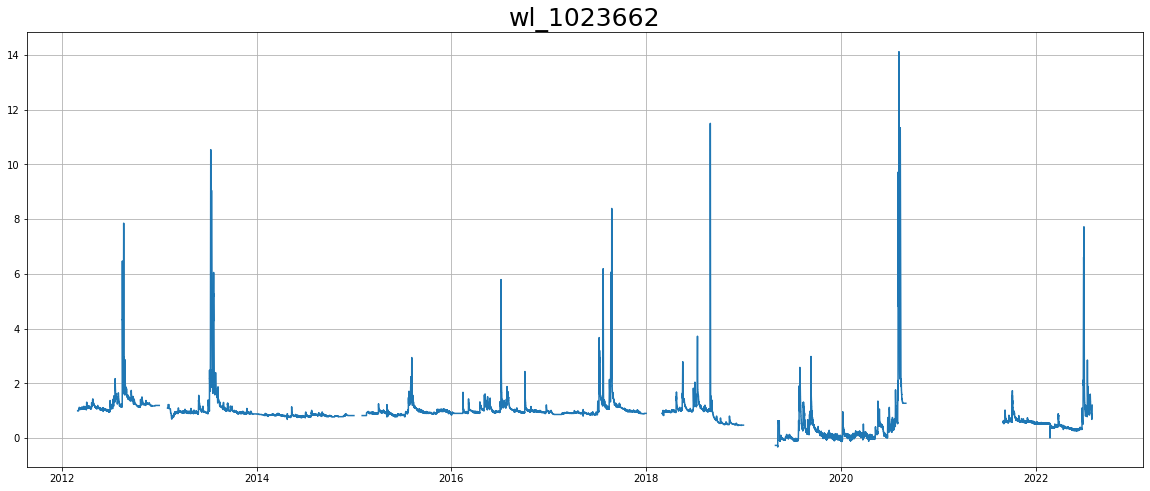

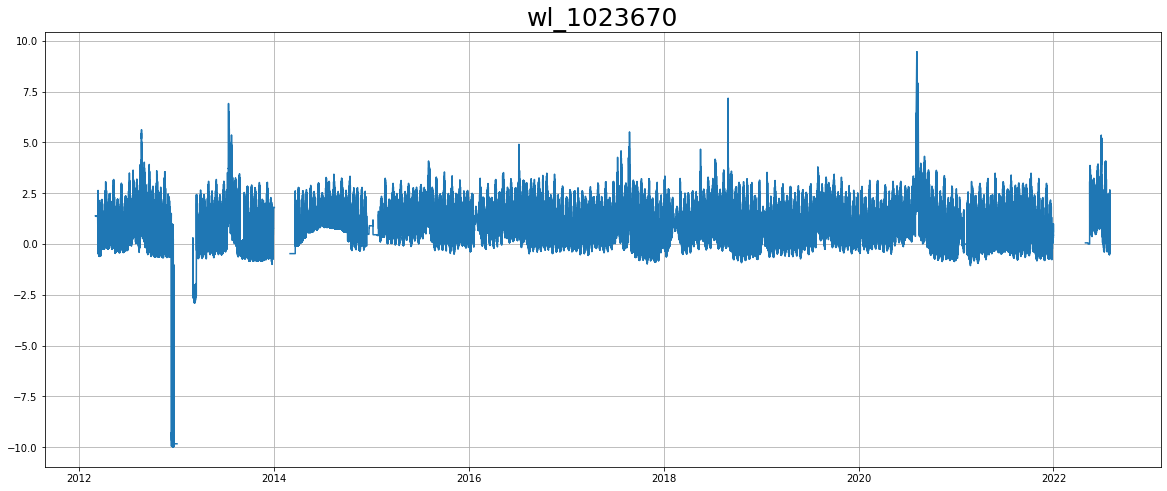

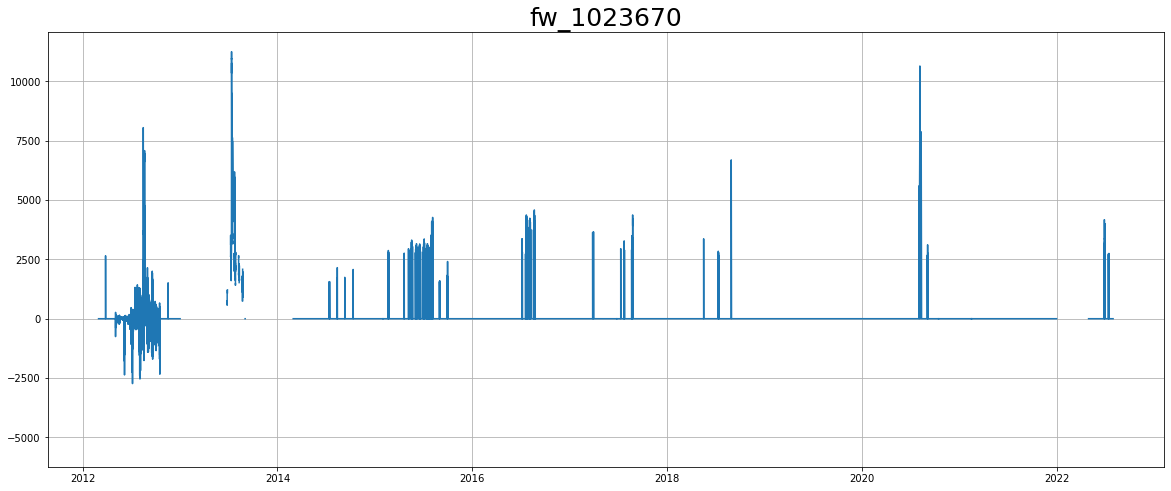

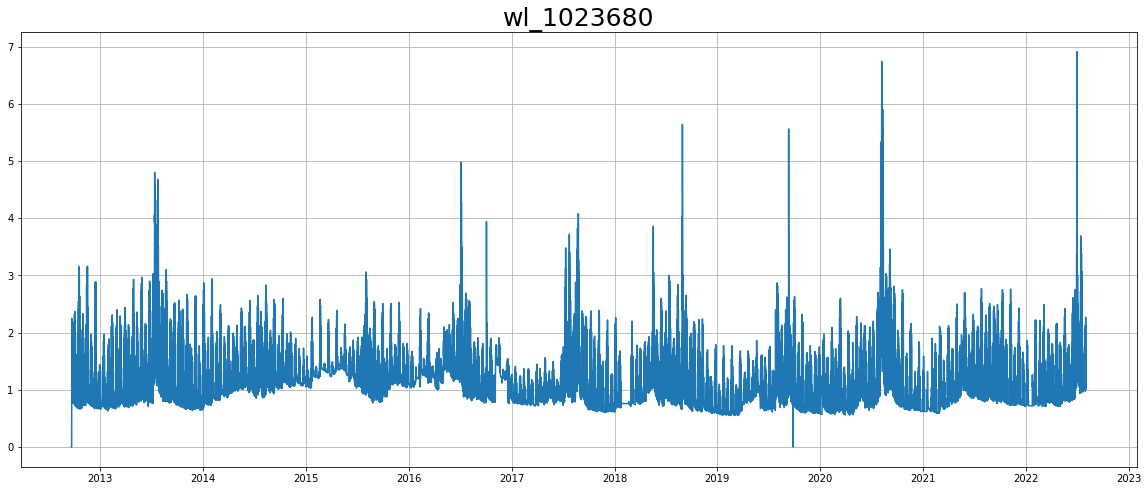

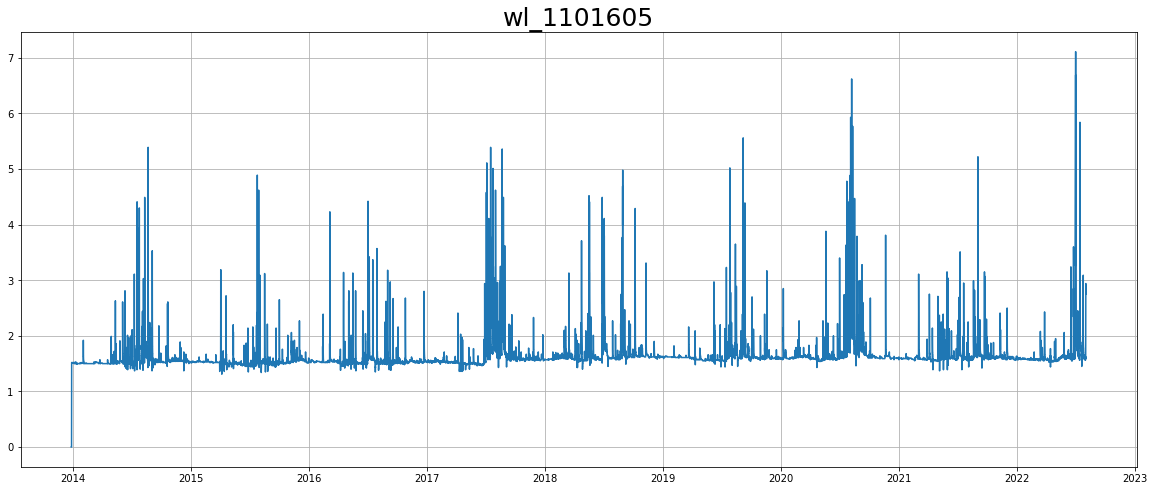

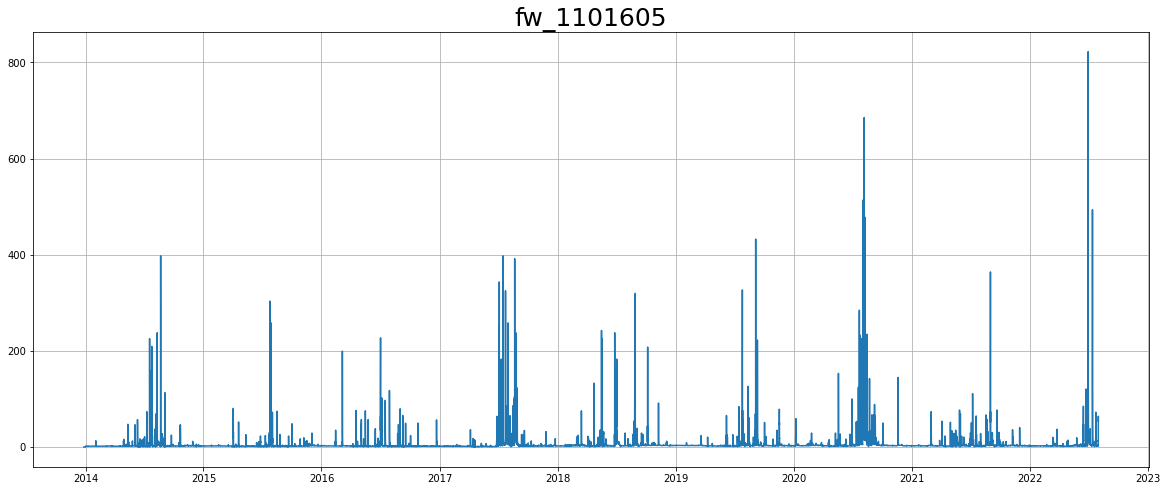

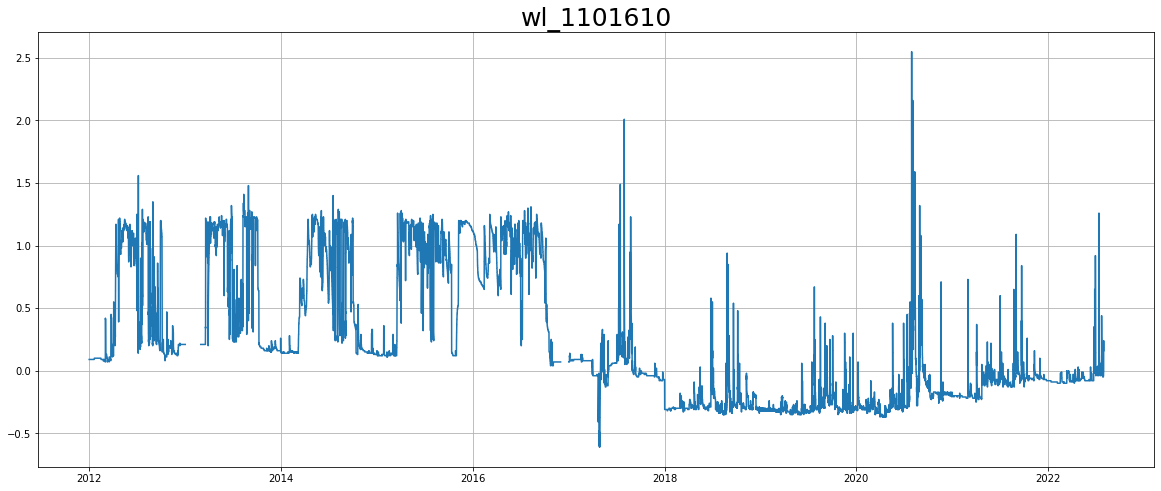

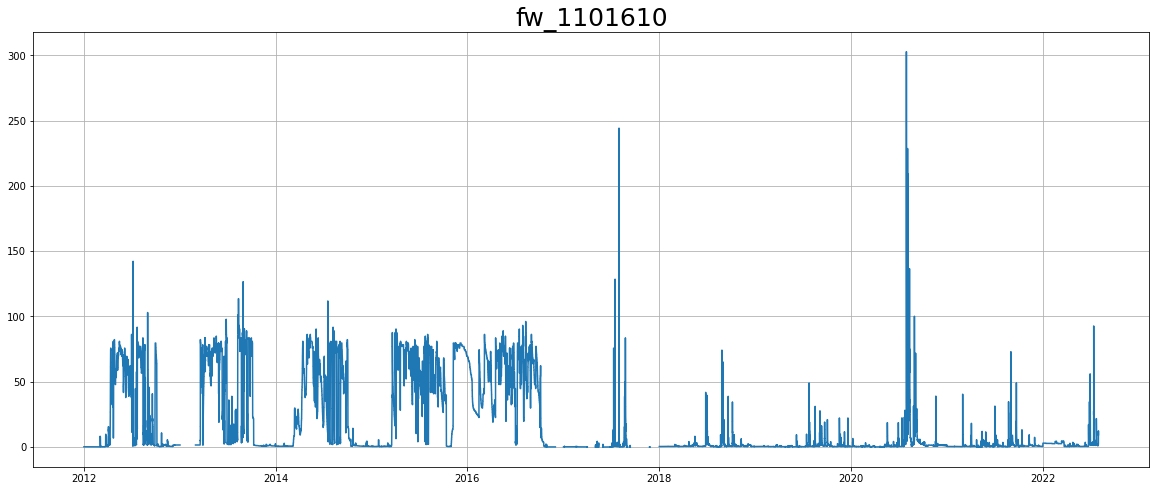

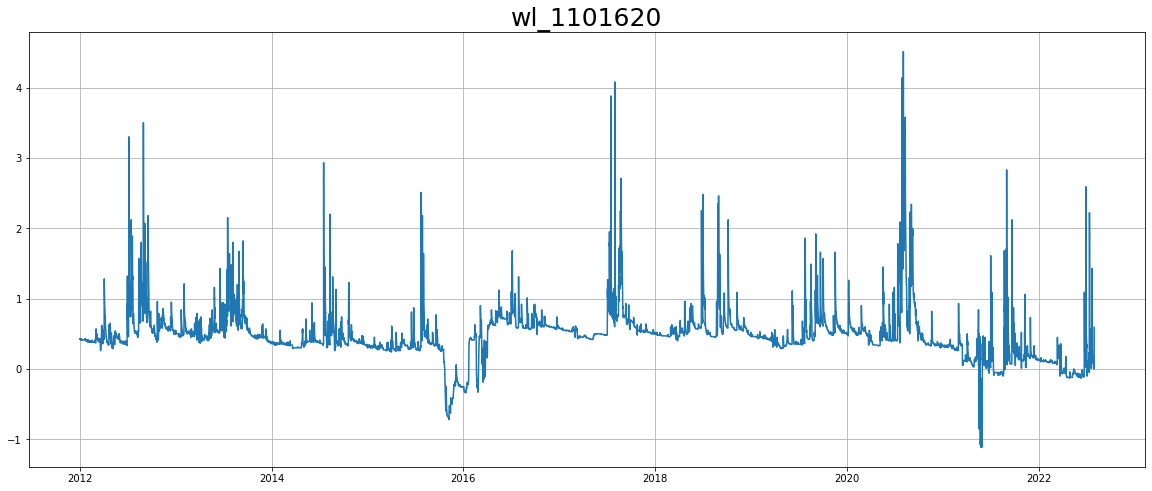

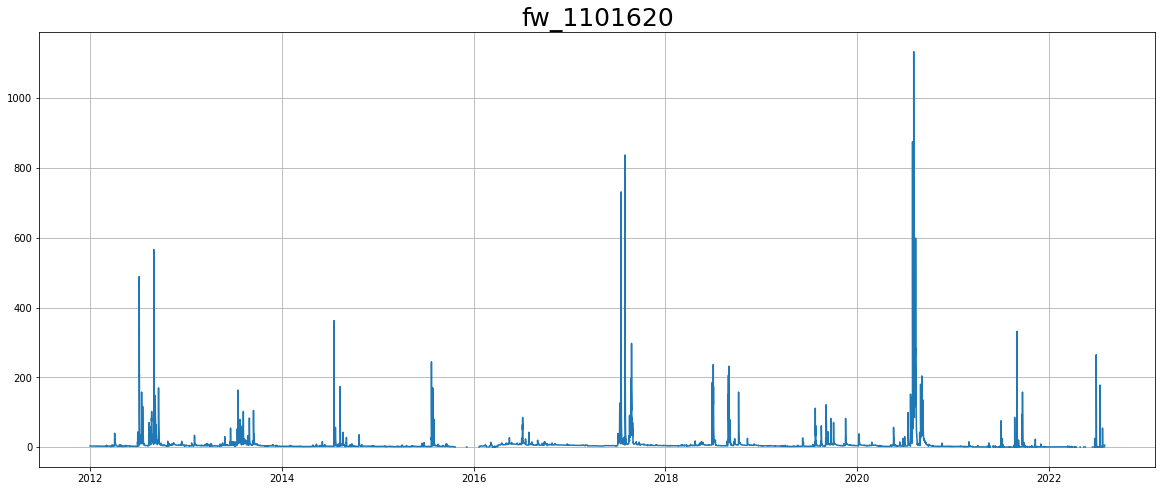

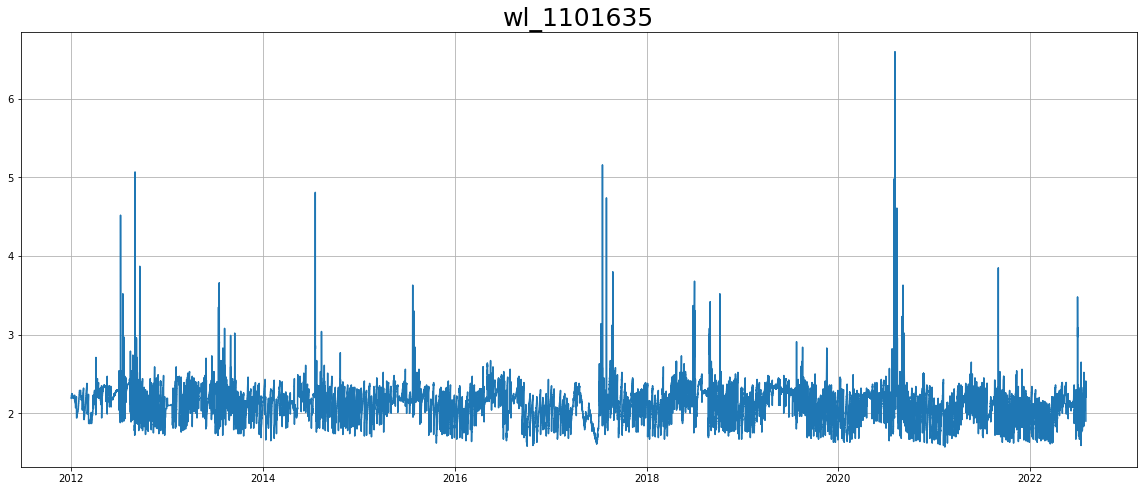

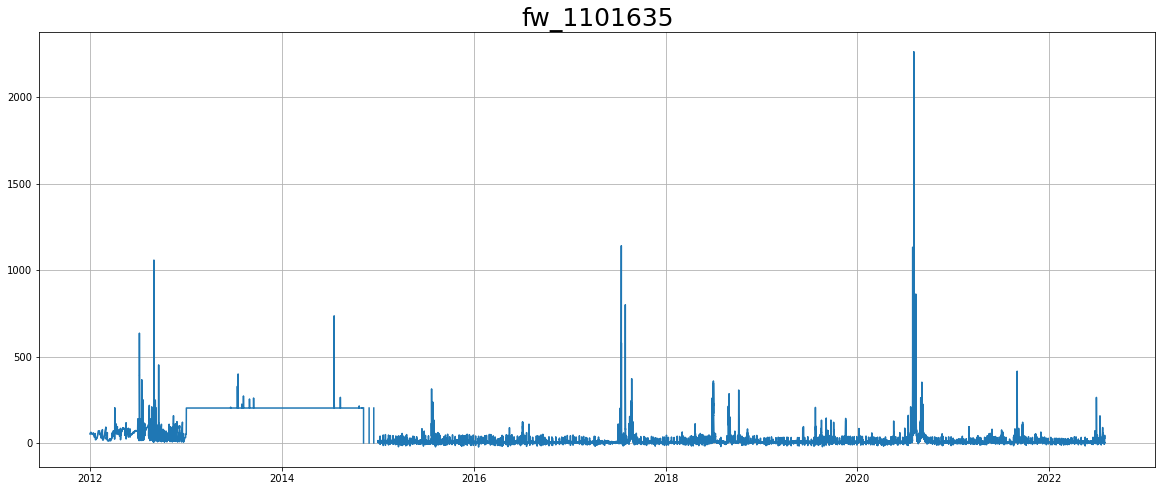

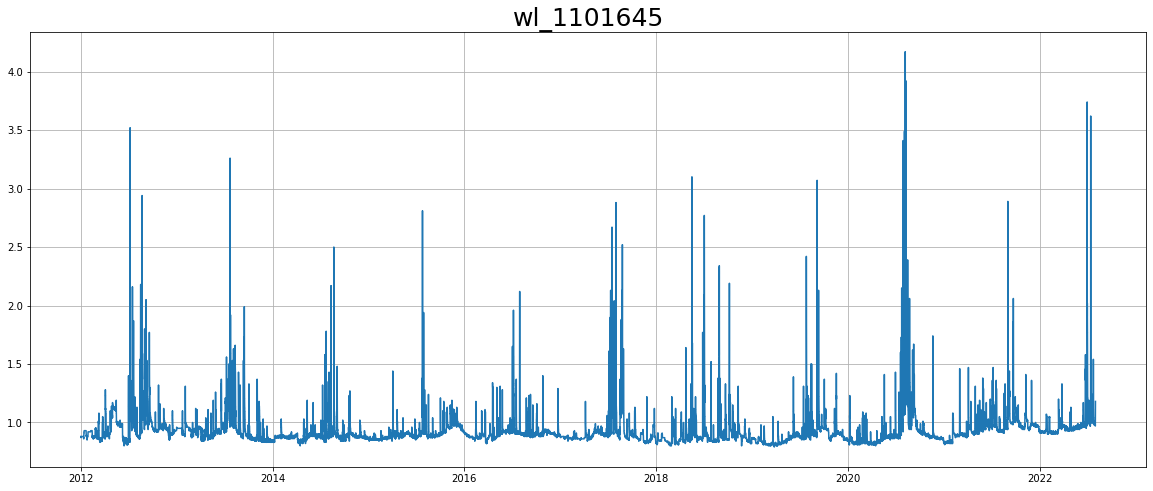

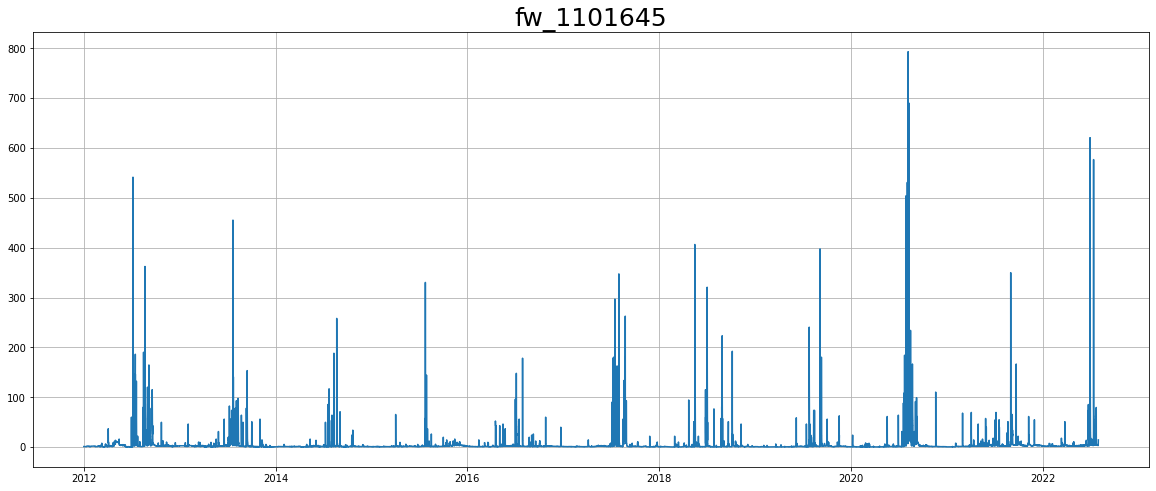

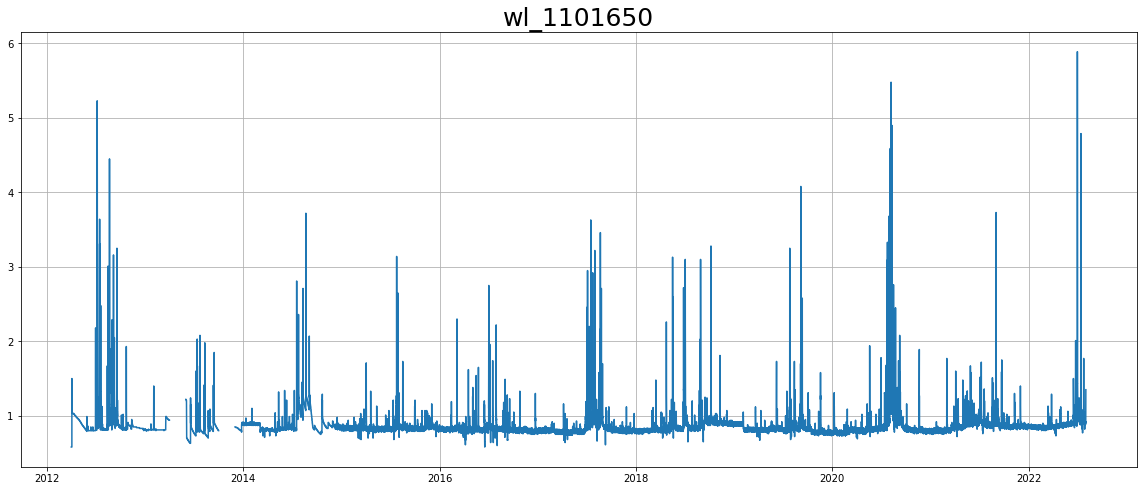

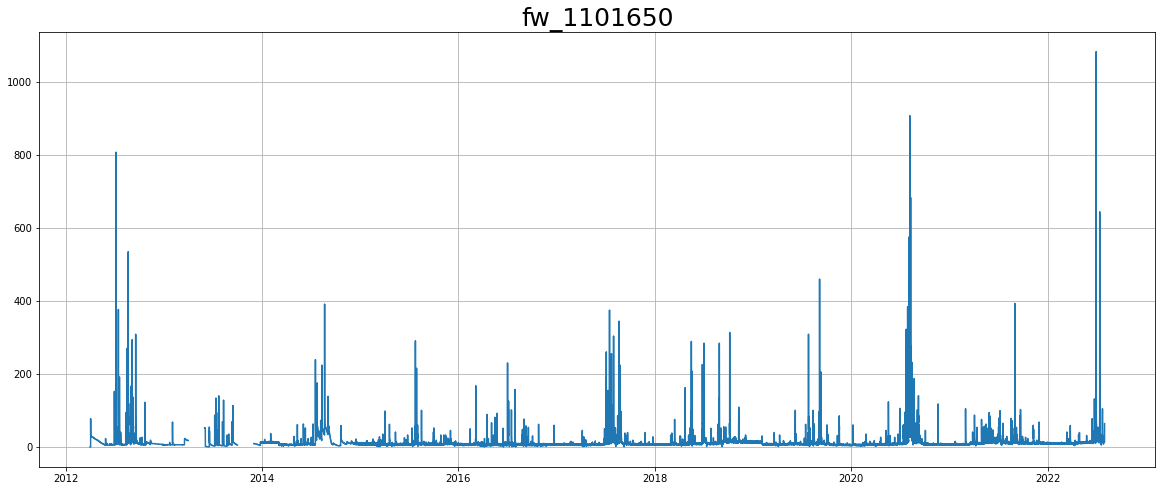

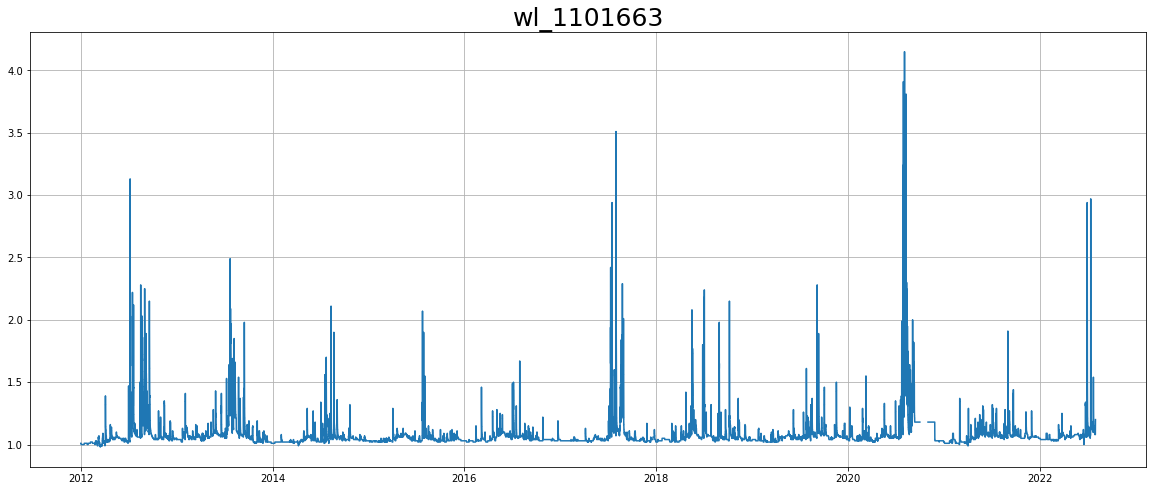

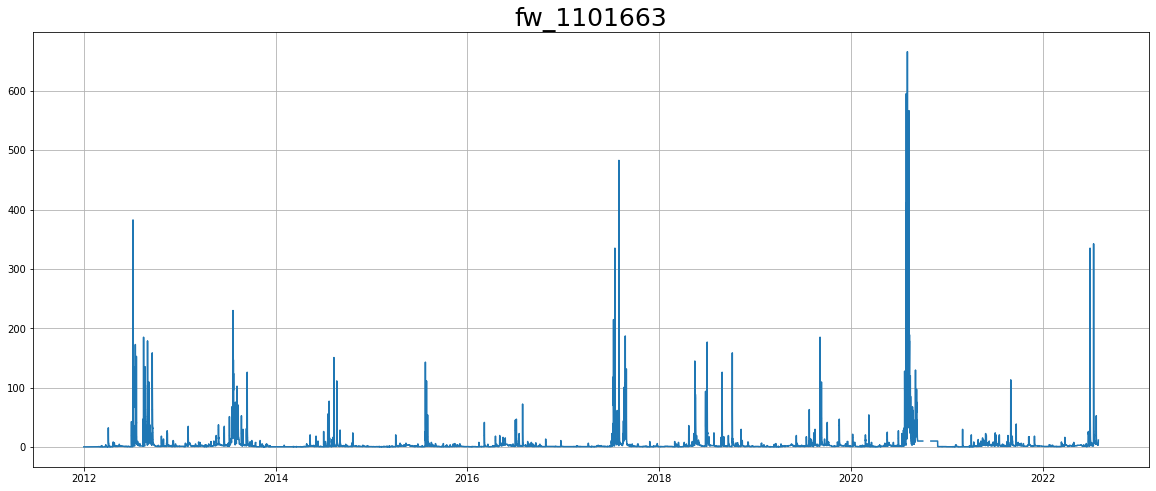

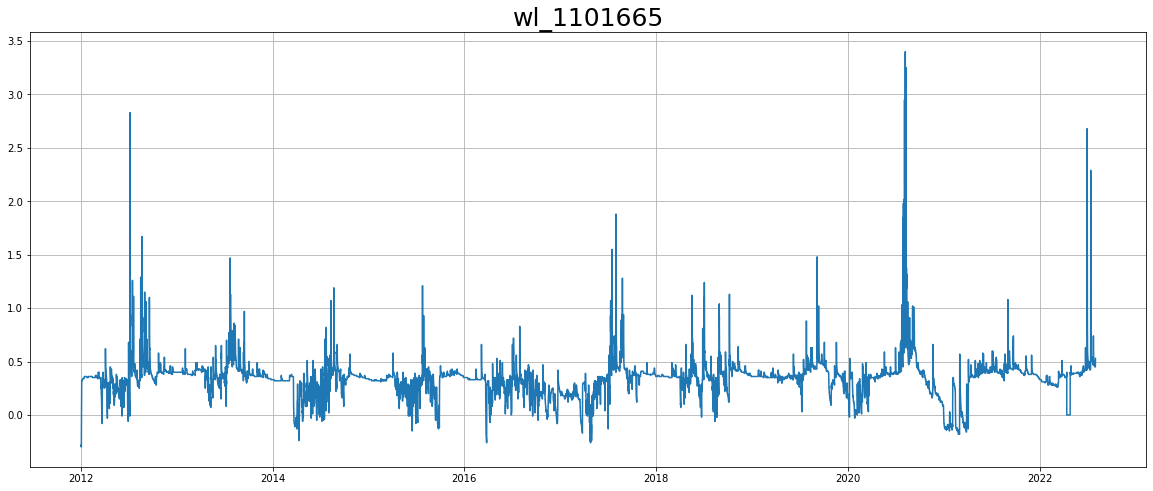

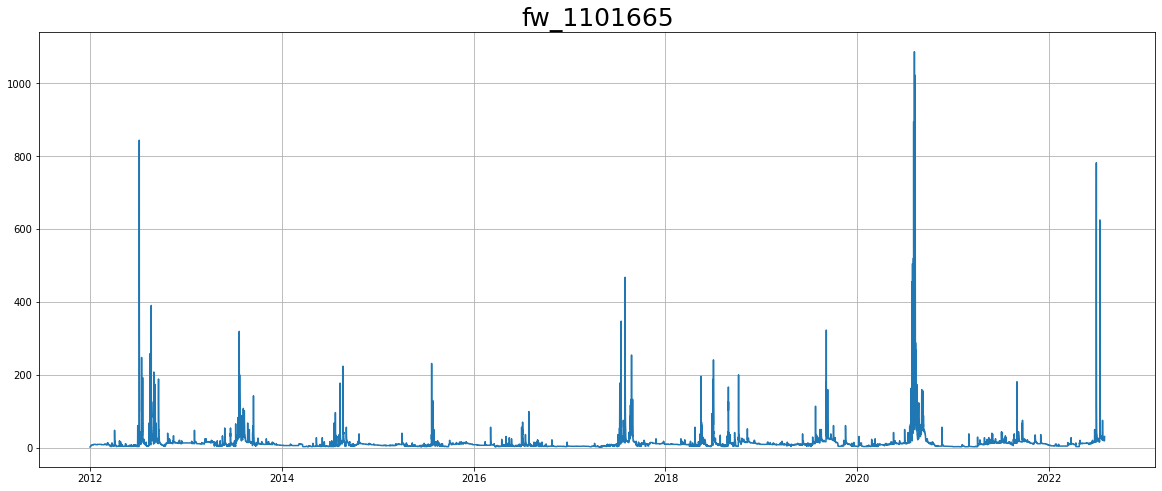

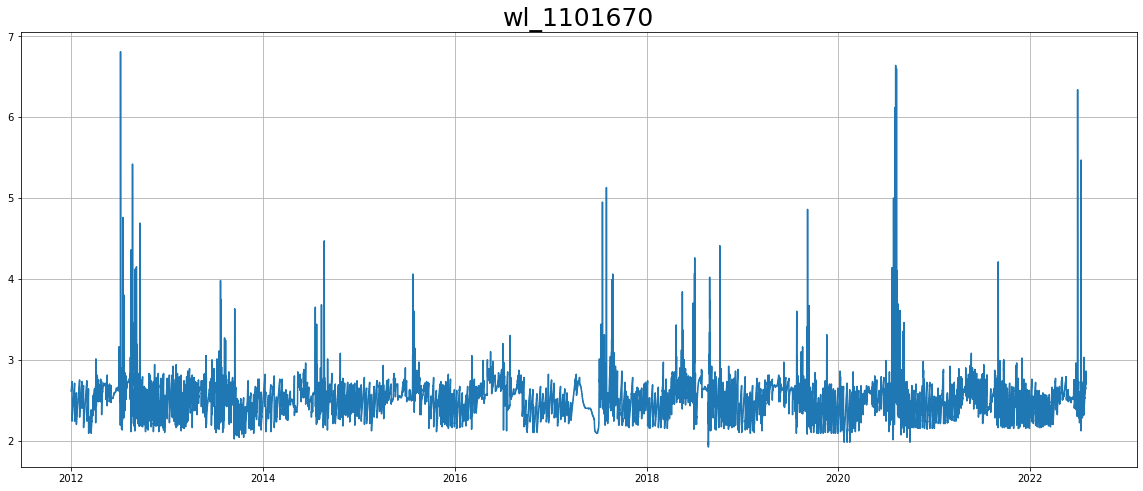

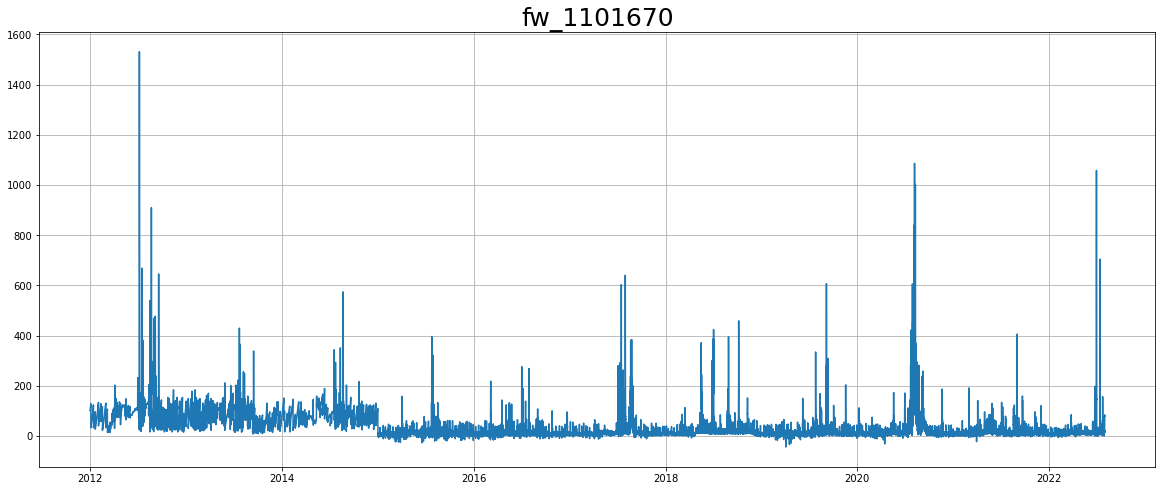

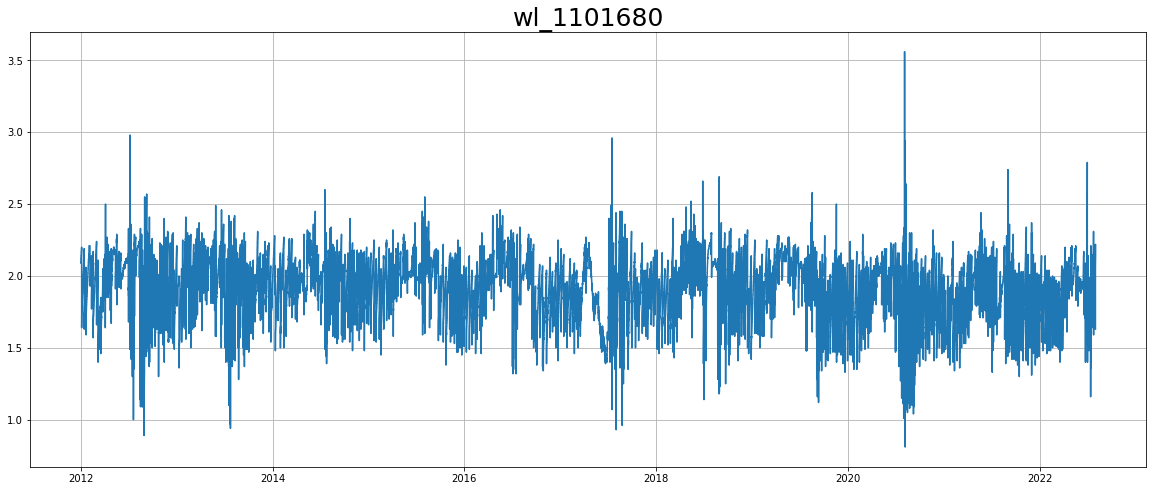

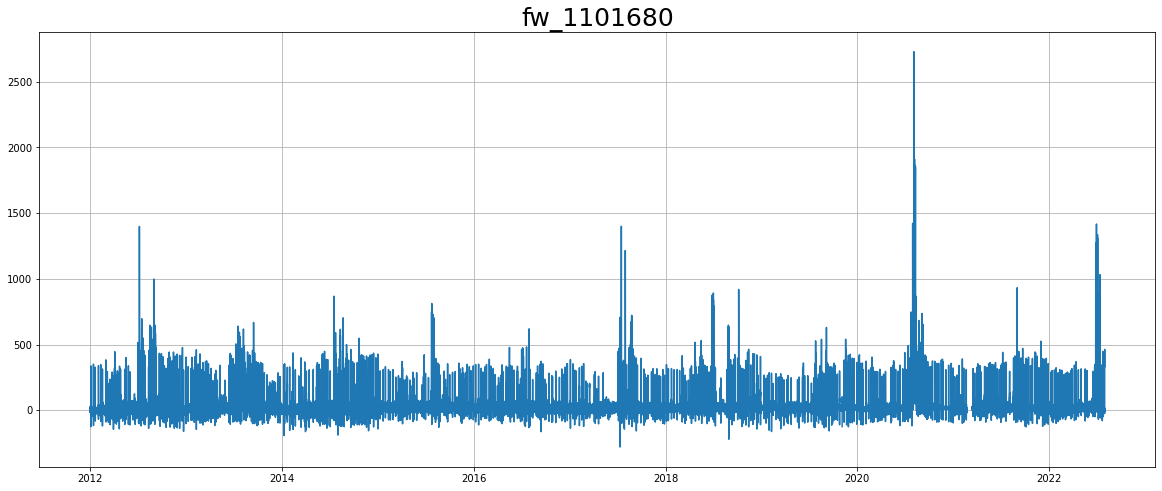

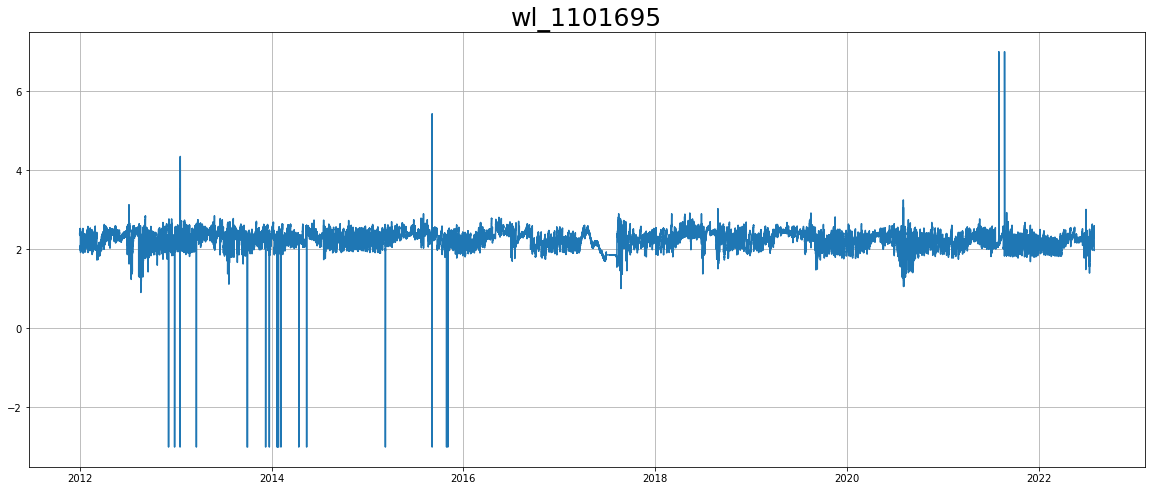

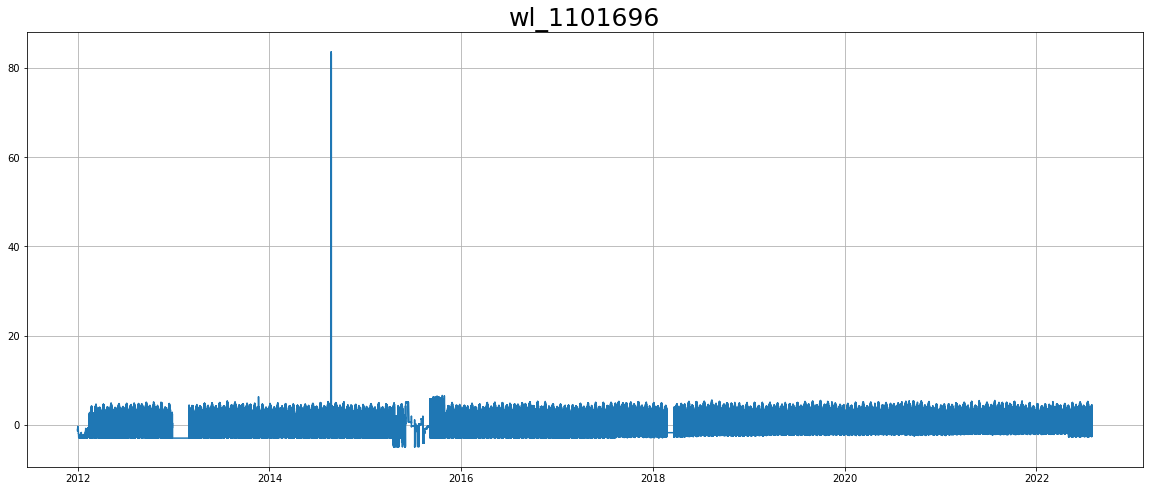

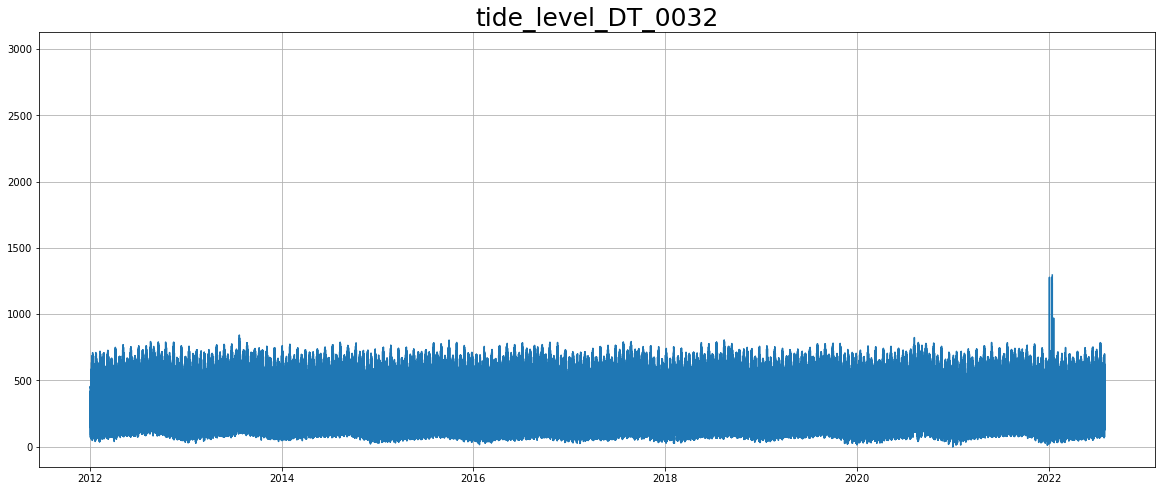

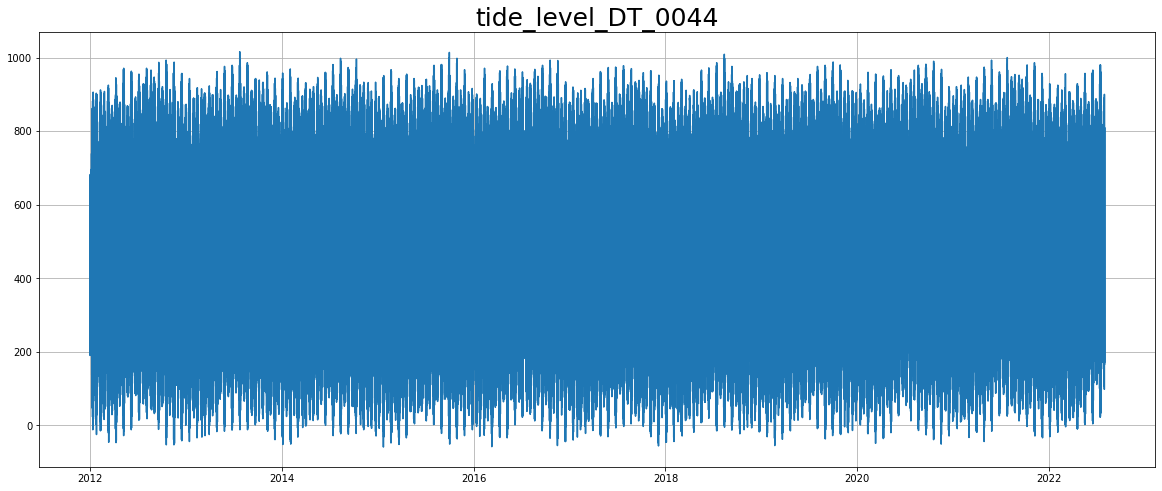

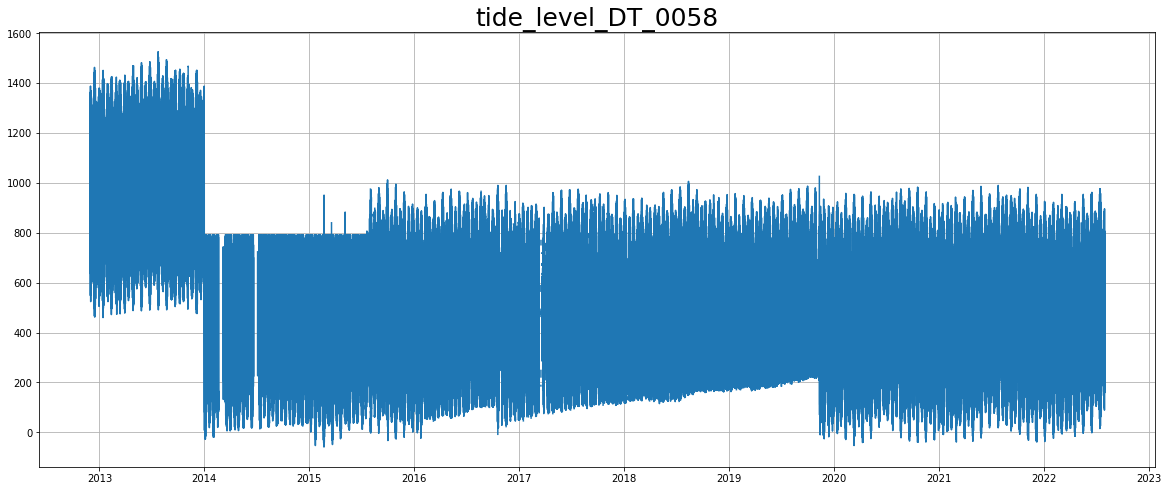

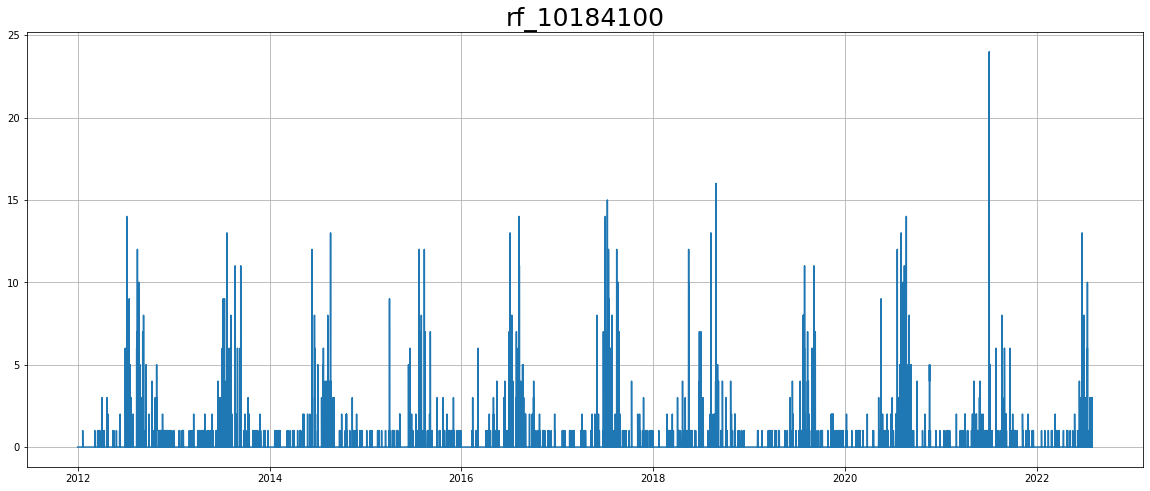

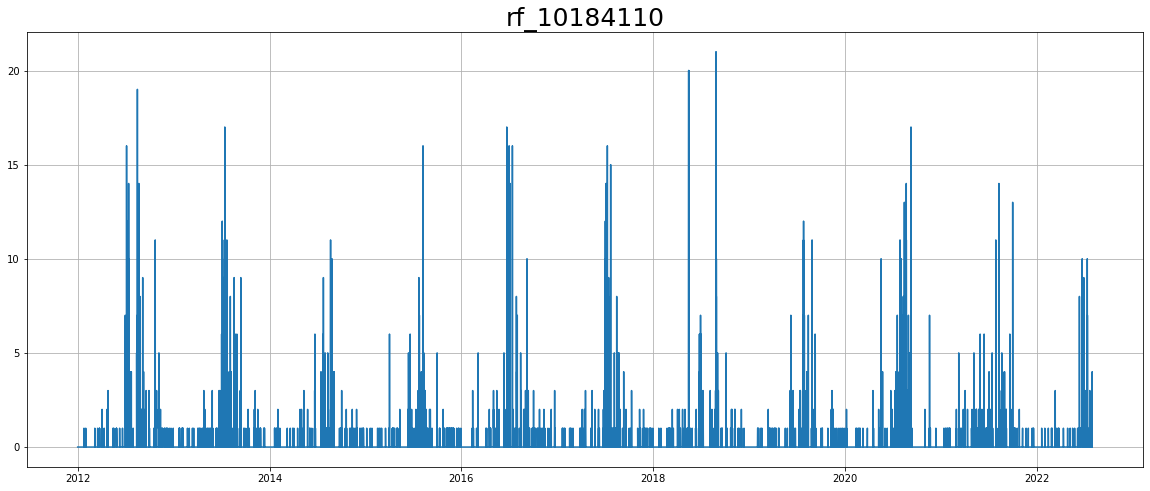

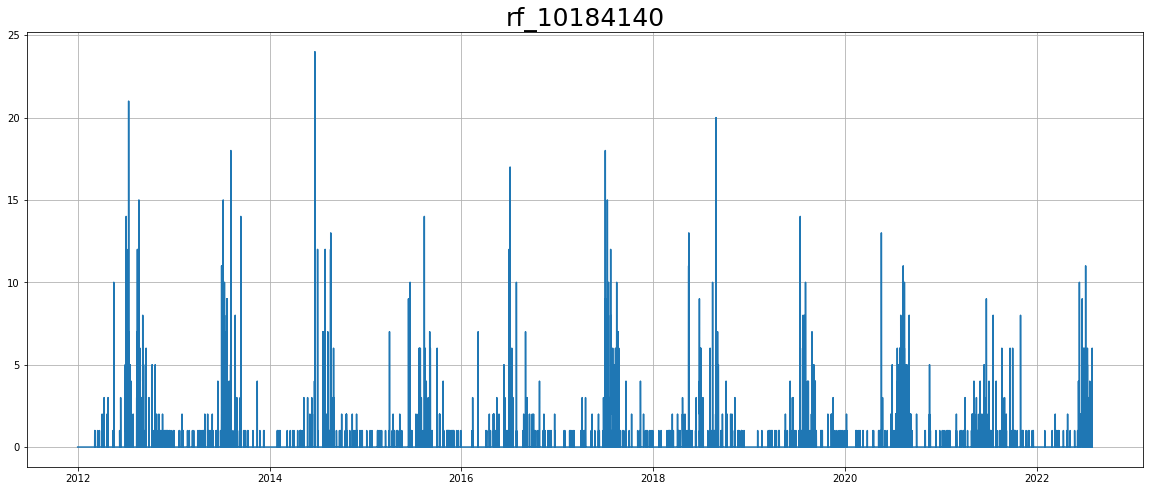

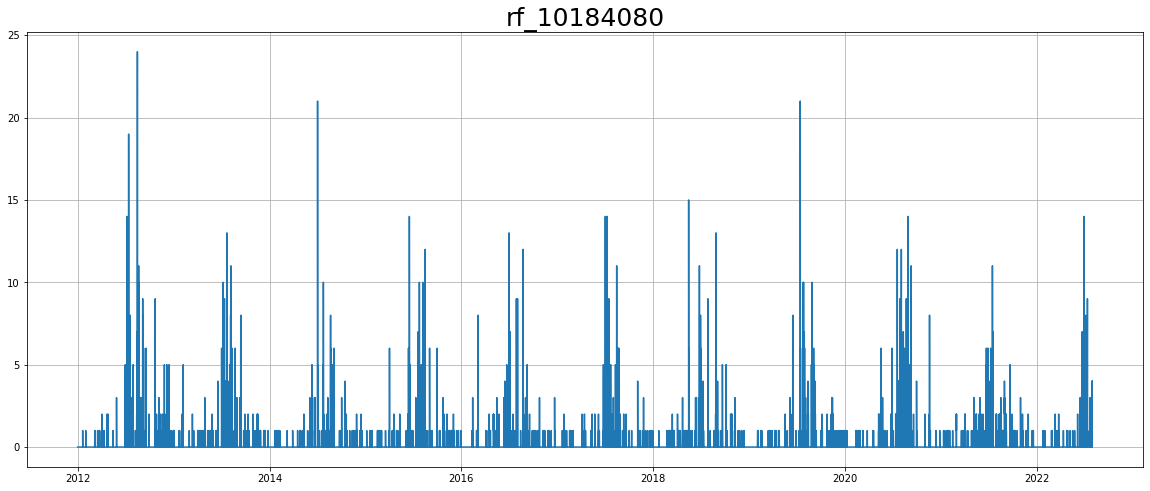

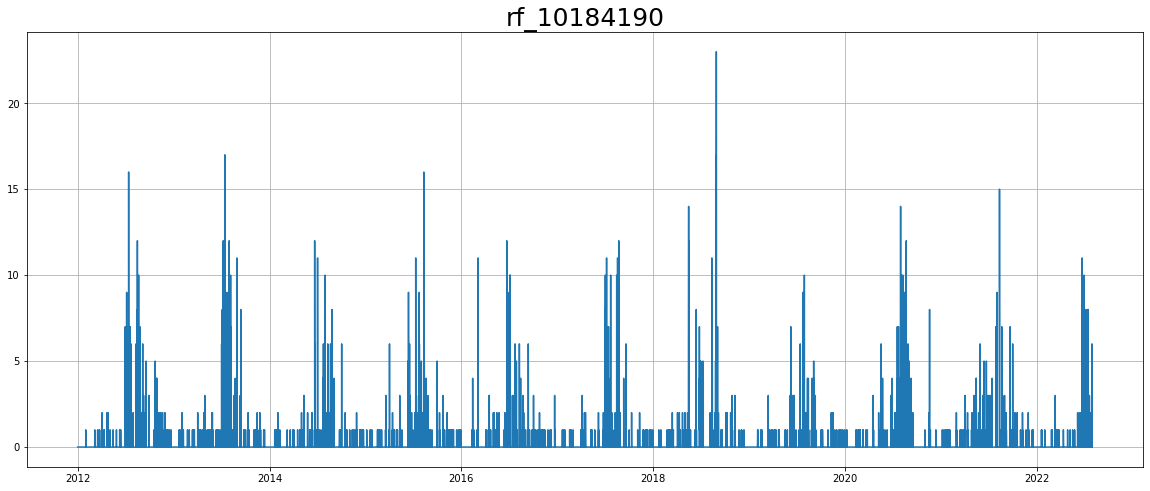

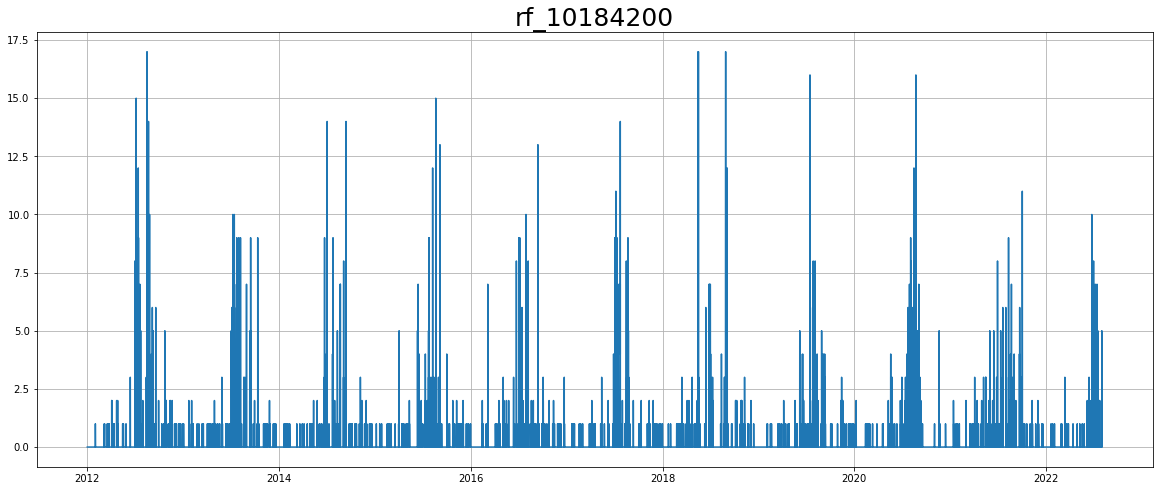

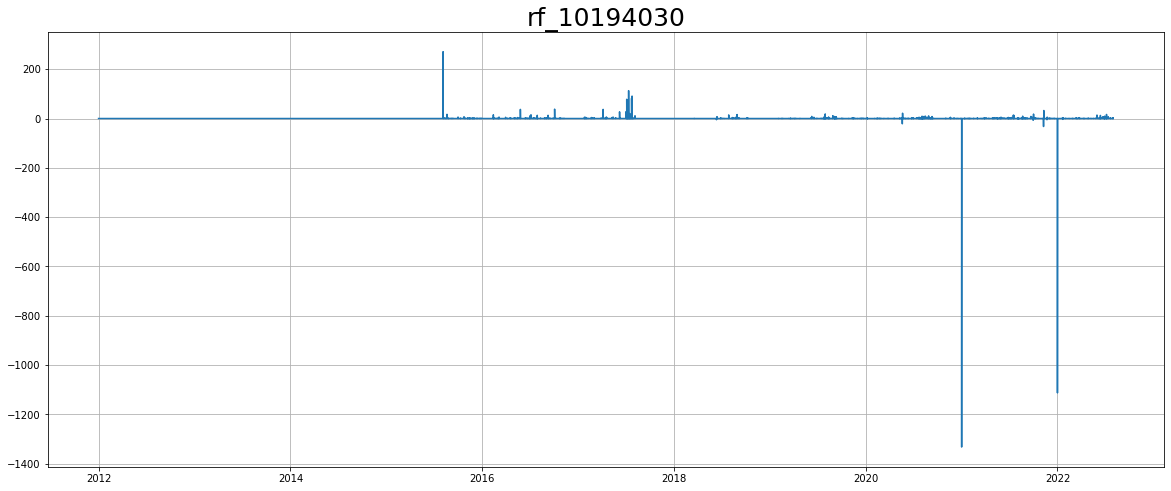

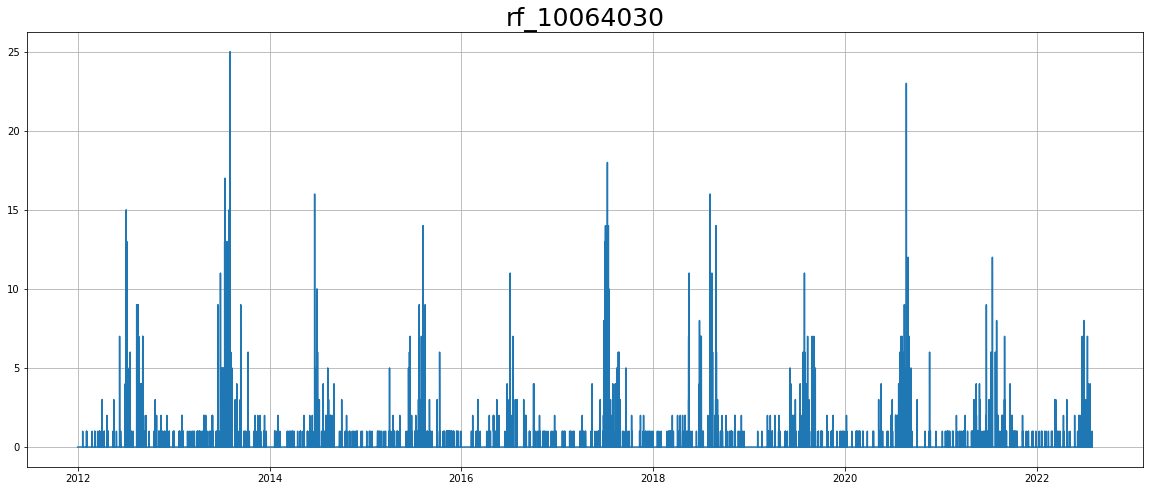

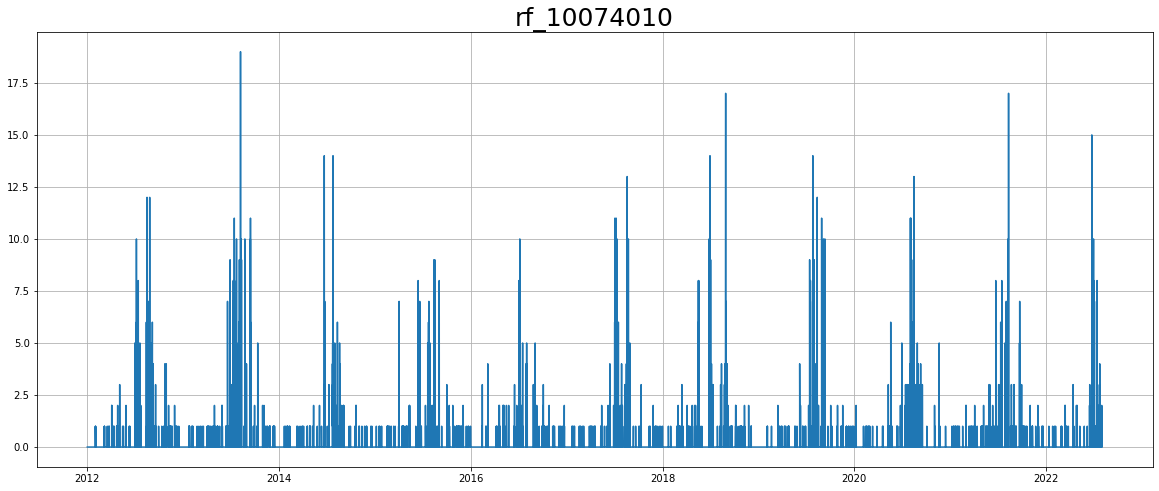

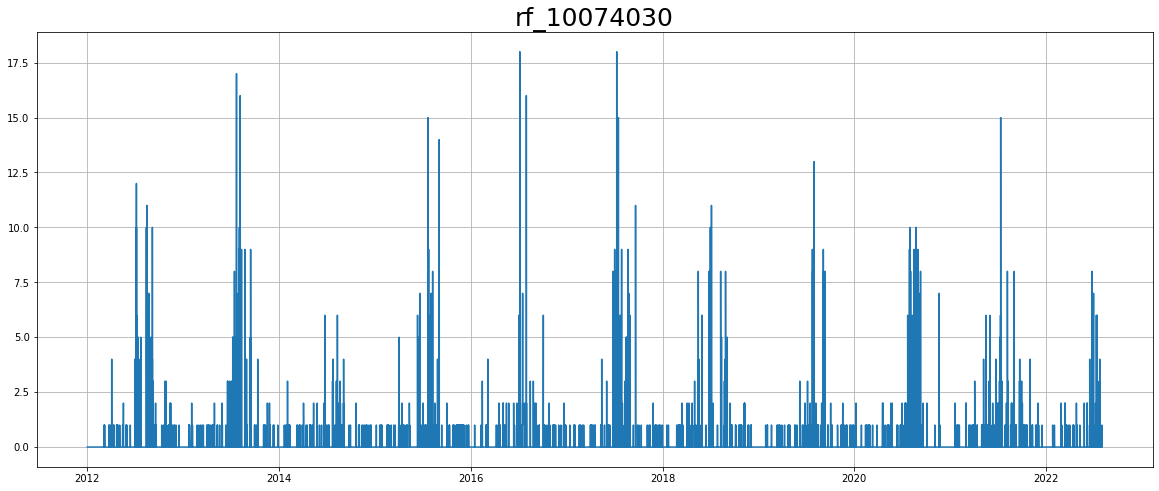

In [97]:
import matplotlib.pyplot as plt

for i in range(120, 160):
    plt.figure(figsize=(20, 8))
    plt.plot(df['ymdhm'], df.iloc[:, i+1])
    plt.title(df.columns[i+1], fontsize=25)
    plt.grid(); plt.show(); plt.close();

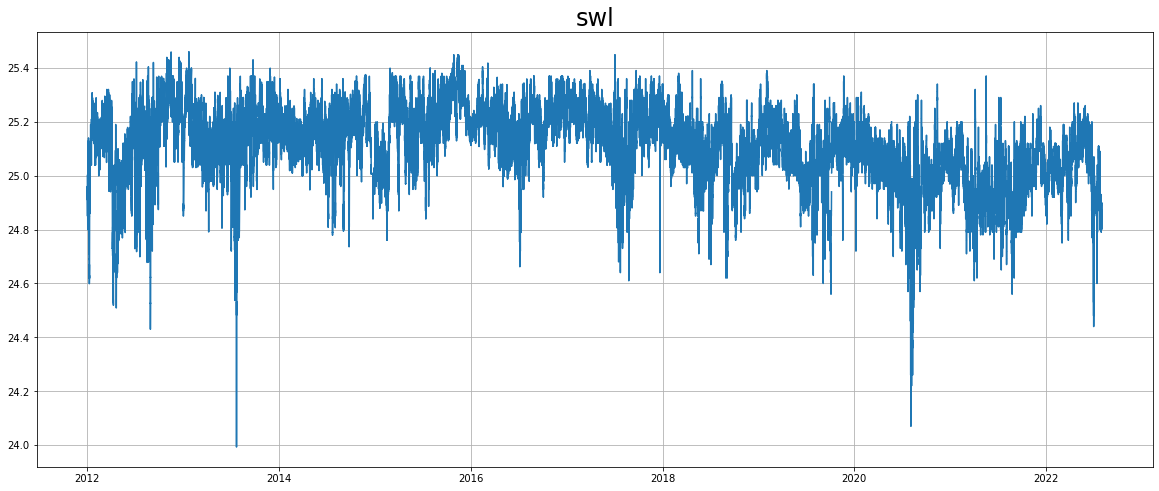

In [19]:
col_name = 'swl'
time = df['ymdhm']
mask_tmp = df['ymdhm'] > pd.Timestamp(2000, 1, 1)
# mask_tmp = (df['ymdhm'] >= pd.Timestamp(2015, 1, 11, 14)) & (df['ymdhm'] < pd.Timestamp(2015, 1, 15))
# mask_tmp = (df['ymdhm'] >= pd.Timestamp(2015, 6, 18)) & (df['ymdhm'] < pd.Timestamp(2015, 6, 19))
ser = df[col_name].copy()

ser[ser <= 0] = np.nan
ser[ser >= 50] = np.nan
ser[time == pd.Timestamp(2016, 3, 5, 14, 50)] = np.nan

plt.figure(figsize=(20, 8))
plt.plot(df['ymdhm'][mask_tmp], ser[mask_tmp])
plt.title(col_name, fontsize=24)
plt.grid(); plt.show(); plt.close();

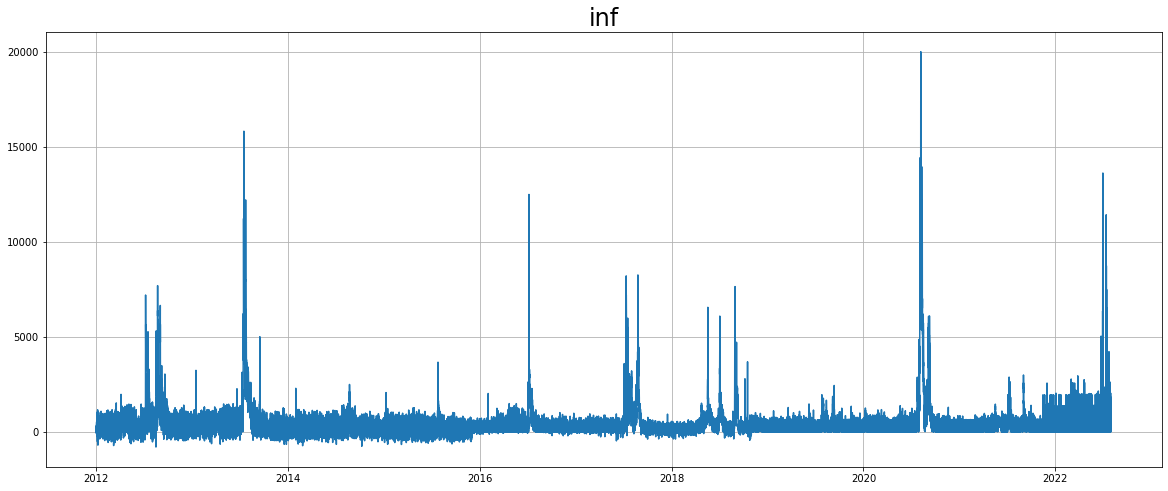

In [7]:
col_name = 'inf'
time = df['ymdhm']
mask_tmp = df['ymdhm'] > pd.Timestamp(2000, 1, 1)
# mask_tmp = (df['ymdhm'] >= pd.Timestamp(2022, 1, 1)) & (df['ymdhm'] < pd.Timestamp(2022, 8, 1))
ser = df[col_name].copy()
ser[time.isin([
    pd.Timestamp(2013, 6, 5, 9, 50),
    pd.Timestamp(2015, 4, 28, 10, 30),
    pd.Timestamp(2016, 5, 23, 16, 10), 
    pd.Timestamp(2017, 12, 21, 5, 30), 
    pd.Timestamp(2017, 12, 21, 5, 40),
    pd.Timestamp(2018, 7, 5, 16, 40),
    pd.Timestamp(2021, 7, 9, 11, 40),
])] = np.nan

plt.figure(figsize=(20, 8))
plt.plot(df['ymdhm'][mask_tmp], ser[mask_tmp])
plt.title(col_name, fontsize=24)
plt.grid(); plt.show(); plt.close();

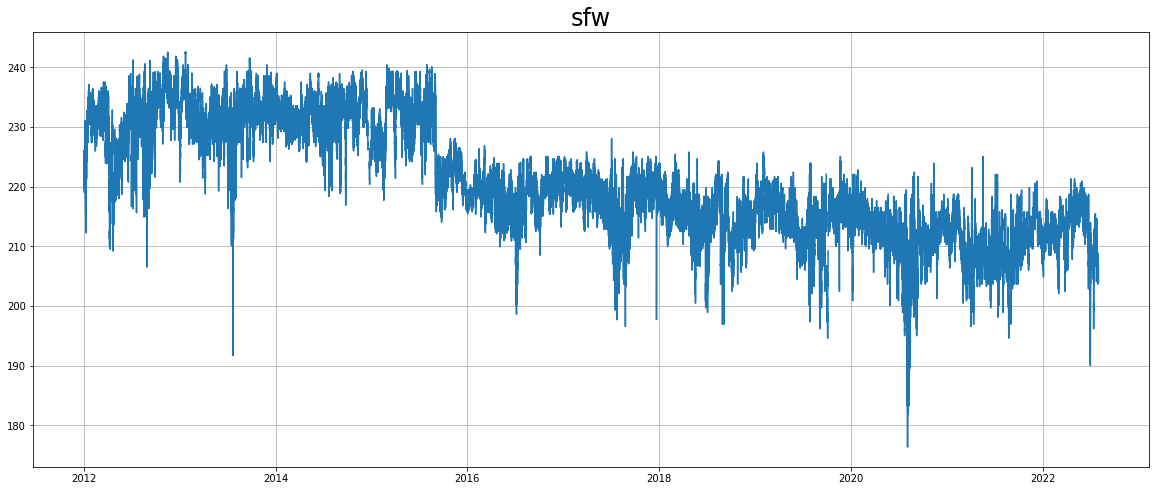

In [11]:
col_name = 'sfw'
time = df['ymdhm']
mask_tmp = df['ymdhm'] > pd.Timestamp(2000, 1, 1)
# mask_tmp = (df['ymdhm'] >= pd.Timestamp(2016, 5, 17)) & (df['ymdhm'] < pd.Timestamp(2016, 5, 17, 12))
ser = df[col_name].copy()

ser[ser == 0] = np.nan
ser[time.isin([
    pd.Timestamp(2016, 3, 5, 14, 50),
    pd.Timestamp(2016, 5, 17, 2),
    pd.Timestamp(2018, 7, 5, 16, 40)
])] = np.nan

plt.figure(figsize=(20, 8))
plt.plot(df['ymdhm'][mask_tmp], ser[mask_tmp])
plt.title(col_name, fontsize=24)
plt.grid(); plt.show(); plt.close();

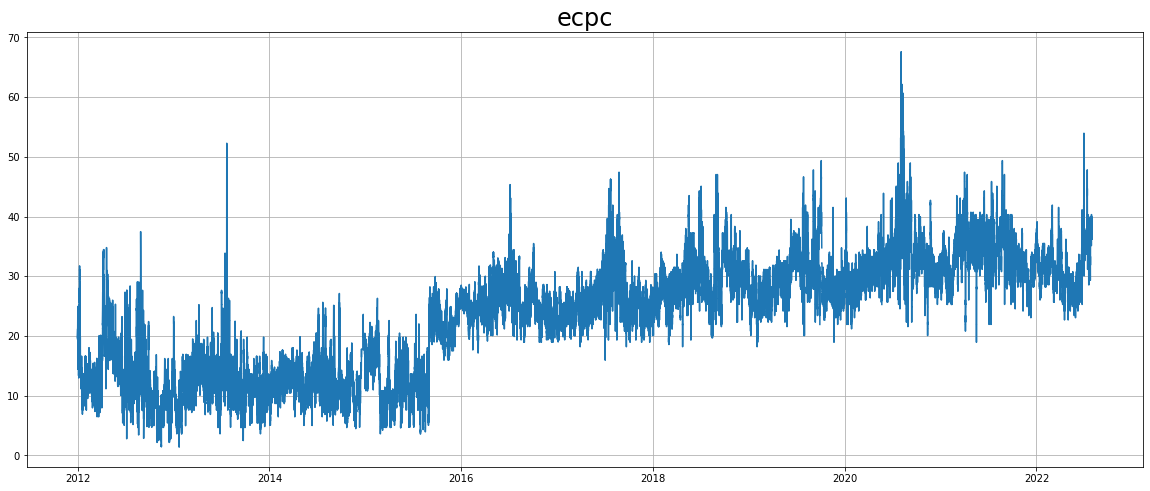

In [33]:
col_name = 'ecpc'
time = df['ymdhm']
mask_tmp = df['ymdhm'] > pd.Timestamp(2000, 1, 1)
# mask_tmp = (df['ymdhm'] >= pd.Timestamp(2017, 2, 15)) & (df['ymdhm'] < pd.Timestamp(2017, 2, 17))
ser = df[col_name].copy()

ser[ser == 244] = np.nan
ser[time.isin([
    pd.Timestamp(2016, 3, 5, 14, 50),
    pd.Timestamp(2016, 5, 17, 2),
    pd.Timestamp(2017, 12, 21, 5, 30), 
    pd.Timestamp(2017, 12, 21, 5, 40),
    pd.Timestamp(2018, 7, 5, 16, 40),
])] = np.nan

plt.figure(figsize=(20, 8))
plt.plot(df['ymdhm'][mask_tmp], ser[mask_tmp])
plt.title(col_name, fontsize=24)
plt.grid(); plt.show(); plt.close();

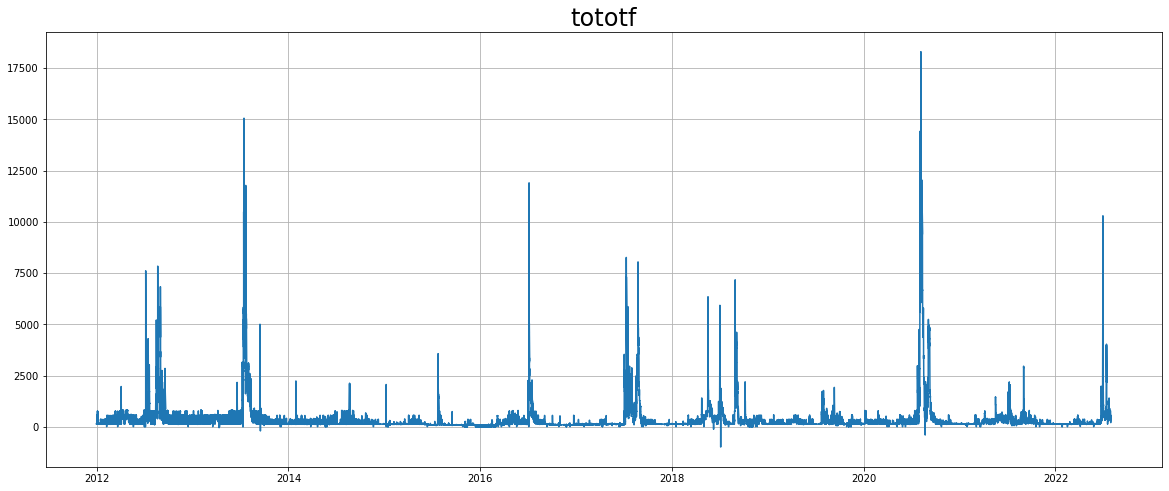

In [40]:
col_name = 'tototf'
time = df['ymdhm']
mask_tmp = df['ymdhm'] > pd.Timestamp(2000, 1, 1)
# mask_tmp = (df['ymdhm'] >= pd.Timestamp(2015, 1, 7)) & (df['ymdhm'] < pd.Timestamp(2015, 1, 9))
ser = df[col_name].copy()

# ser[ser == 244] = np.nan
ser[time.isin([
    pd.Timestamp(2013, 6, 5, 9, 50),
    pd.Timestamp(2015, 4, 28, 10, 30),
    pd.Timestamp(2016, 5, 23, 16, 10), 
    pd.Timestamp(2021, 7, 9, 11, 40),
])] = np.nan

plt.figure(figsize=(20, 8))
plt.plot(df['ymdhm'][mask_tmp], ser[mask_tmp])
plt.title(col_name, fontsize=24)
plt.grid(); plt.show(); plt.close();

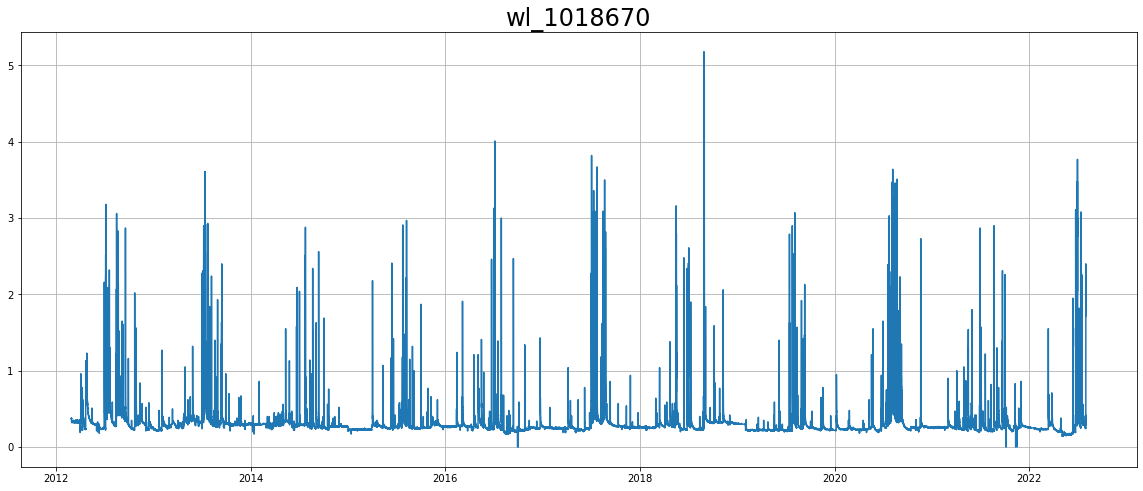

In [57]:
col_name = 'wl_1018670' # 'fw_1018670'
time = df['ymdhm']
mask_tmp = df['ymdhm'] > pd.Timestamp(2000, 1, 1)
# mask_tmp = (df['ymdhm'] >= pd.Timestamp(2012, 2, 27)) & (df['ymdhm'] < pd.Timestamp(2012, 2, 28))
ser = df[col_name].copy()

ser[df['ymdhm'] <= pd.Timestamp(2012, 2, 27, 12)] = np.nan

plt.figure(figsize=(20, 8))
plt.plot(df['ymdhm'][mask_tmp], ser[mask_tmp])
plt.title(col_name, fontsize=24)
plt.grid(); plt.show(); plt.close();

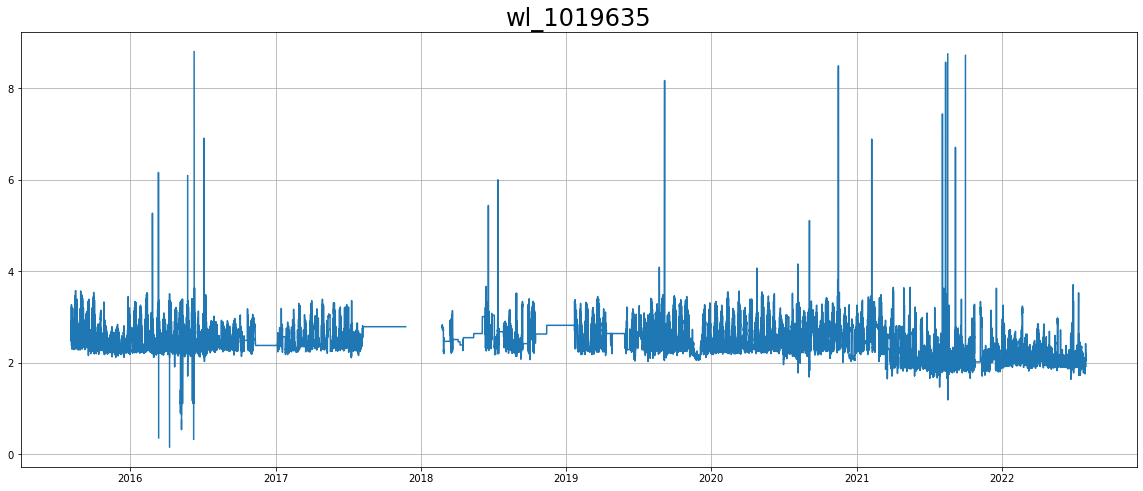

In [96]:
col_name = 'wl_1019635' # 'wl_1007633', 'wl_1007639', 'wl_1007641', 'wl_1007662', 'wl_1007664', 'wl_1015640' 
time = df['ymdhm']
mask_tmp = df['ymdhm'] > pd.Timestamp(2000, 1, 1)
# mask_tmp = (df['ymdhm'] >= pd.Timestamp(2012, 2, 27)) & (df['ymdhm'] < pd.Timestamp(2012, 2, 28))
ser = df[col_name].copy()

ser[ser <= 0] = np.nan

plt.figure(figsize=(20, 8))
plt.plot(df['ymdhm'][mask_tmp], ser[mask_tmp])
plt.title(col_name, fontsize=24)
plt.grid(); plt.show(); plt.close();

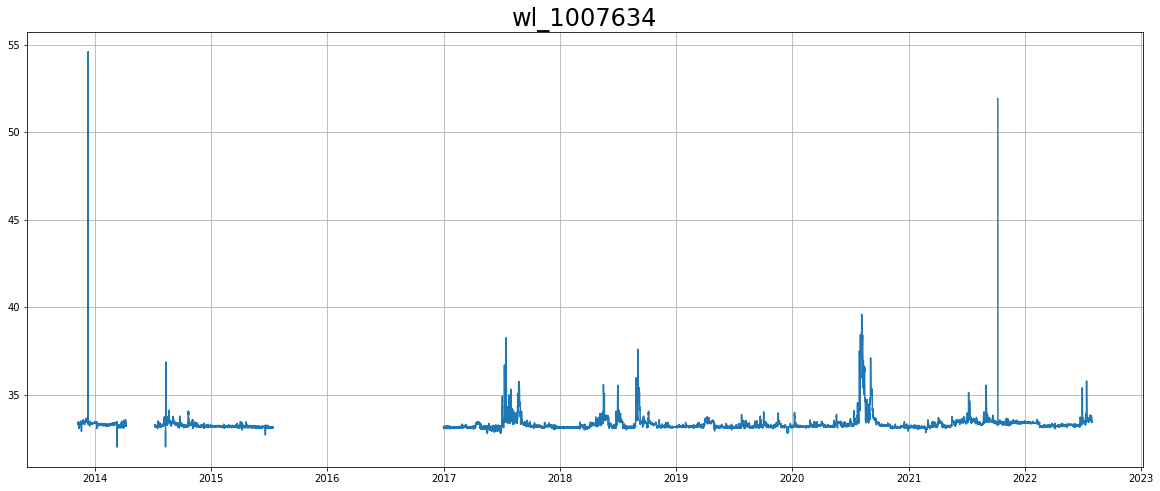

In [69]:
col_name = 'wl_1007634' 
time = df['ymdhm']
mask_tmp = df['ymdhm'] > pd.Timestamp(2000, 1, 1)
# mask_tmp = (df['ymdhm'] >= pd.Timestamp(2021, 8, 1)) & (df['ymdhm'] < pd.Timestamp(2021, 11, 1))
ser = df[col_name].copy()

ser[ser == 0] = np.nan
ser[ser < 30] = np.nan

plt.figure(figsize=(20, 8))
plt.plot(df['ymdhm'][mask_tmp], ser[mask_tmp])
plt.title(col_name, fontsize=24)
plt.grid(); plt.show(); plt.close();

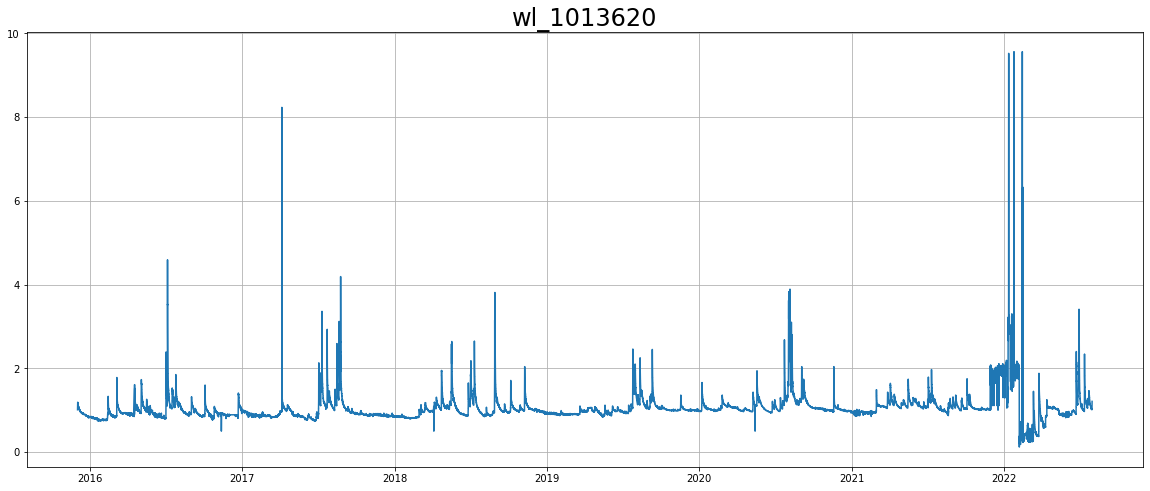

In [85]:
col_name = 'wl_1013620' 
time = df['ymdhm']
mask_tmp = df['ymdhm'] > pd.Timestamp(2000, 1, 1)
# mask_tmp = (df['ymdhm'] >= pd.Timestamp(2021, 8, 1)) & (df['ymdhm'] < pd.Timestamp(2021, 11, 1))
ser = df[col_name].copy()

ser[ser <= 0] = np.nan
ser[ser > 80] = np.nan

plt.figure(figsize=(20, 8))
plt.plot(df['ymdhm'][mask_tmp], ser[mask_tmp])
plt.title(col_name, fontsize=24)
plt.grid(); plt.show(); plt.close();

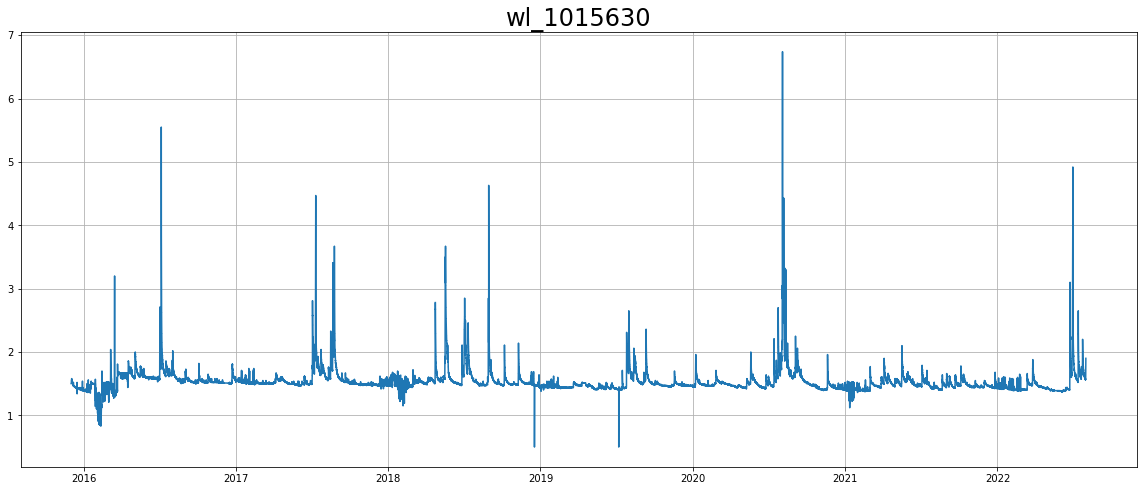

In [88]:
col_name = 'wl_1015630' 
time = df['ymdhm']
mask_tmp = df['ymdhm'] > pd.Timestamp(2000, 1, 1)
# mask_tmp = (df['ymdhm'] >= pd.Timestamp(2021, 8, 1)) & (df['ymdhm'] < pd.Timestamp(2021, 11, 1))
ser = df[col_name].copy()

ser[ser <= 0] = np.nan
ser[ser > 40] = np.nan

plt.figure(figsize=(20, 8))
plt.plot(df['ymdhm'][mask_tmp], ser[mask_tmp])
plt.title(col_name, fontsize=24)
plt.grid(); plt.show(); plt.close();

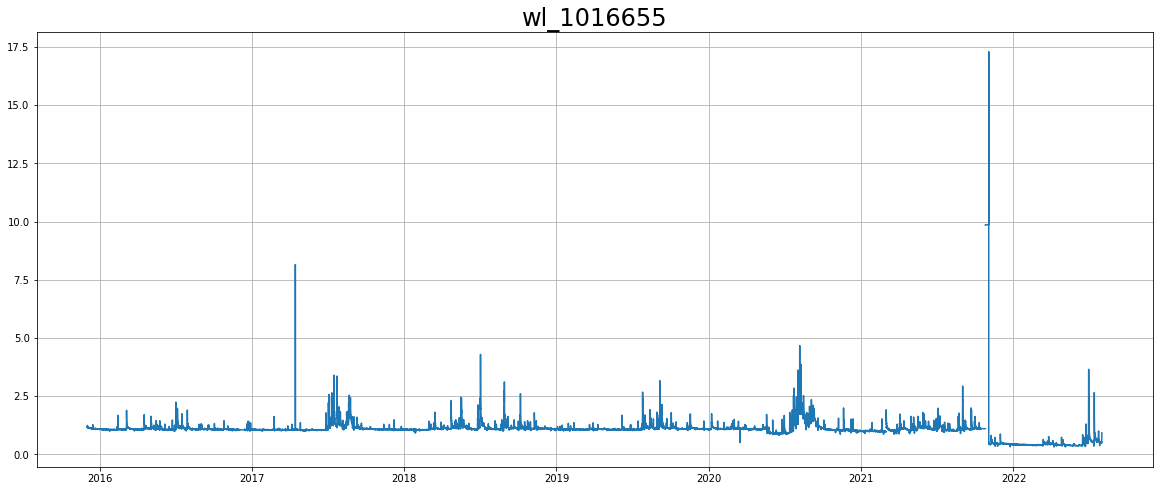

In [93]:
col_name = 'wl_1016655'
time = df['ymdhm']
mask_tmp = df['ymdhm'] > pd.Timestamp(2000, 1, 1)
# mask_tmp = (df['ymdhm'] >= pd.Timestamp(2021, 8, 1)) & (df['ymdhm'] < pd.Timestamp(2021, 11, 1))
ser = df[col_name].copy()

ser[ser <= 0] = np.nan
ser[ser > 30] = np.nan

plt.figure(figsize=(20, 8))
plt.plot(df['ymdhm'][mask_tmp], ser[mask_tmp])
plt.title(col_name, fontsize=24)
plt.grid(); plt.show(); plt.close();

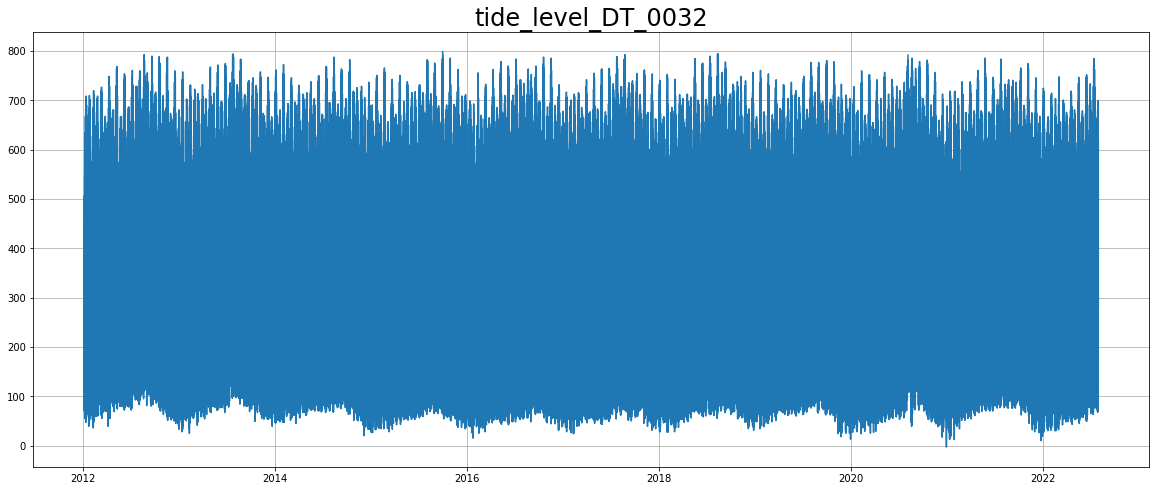

In [132]:
col_name = 'tide_level_DT_0032'
time = df['ymdhm']
mask_tmp = df['ymdhm'] > pd.Timestamp(2000, 1, 1)
# mask_tmp = (df['ymdhm'] >= pd.Timestamp(2022, 1, 13, 22)) & (df['ymdhm'] < pd.Timestamp(2022, 1, 14))# 19))
ser = df[col_name].copy()

ser[ser > 800] = np.nan
ser[df['ymdhm'].isin([
    pd.Timestamp(2022, 1, 2, 13, 10),
    pd.Timestamp(2022, 1, 12, 7),
    pd.Timestamp(2022, 1, 13, 6, 30),
    pd.Timestamp(2022, 1, 13, 7, 10), 
    pd.Timestamp(2022, 1, 13, 8, 10),
    pd.Timestamp(2022, 1, 13, 22, 30)
])] = np.nan

plt.figure(figsize=(20, 8))
plt.plot(df['ymdhm'][mask_tmp], ser[mask_tmp])
plt.title(col_name, fontsize=24)
plt.grid(); plt.show(); plt.close();